# Analisis Faktor Risiko Kolesterol

---
## Sumber data
https://www.kaggle.com/datasets/yukeshmarudhasalam/framingham

---
## Keterangan variabel
- `male`: jenis kelamin (0: perempuan, 1: laki-laki)
- `age`: usia (tahun)
- `currentSmoker`: status merokok (0: non-perokok, 1: perokok)
- `cigsPerDay`: jumlah rokok per hari (batang/hari)
- `BPMeds`: sedang mengonsumsi obat tekanan darah atau tidak (0: tidak, 1: ya)
- `prevalentStroke`: riwayat stroke (0: tidak pernah, 1: pernah)
- `prevalentHyp`: riwayat hipertensi (0: tidak, 1: hipertensi)
- `diabetes`: status diabetes (0: tidak, 1: diabetes)
- `sysBP`: tekanan darah sistolik (mmHg)
- `diaBP`: tekanan darah diastolik (mmHg)
- `BMI`: Body Mass Index atau indeks massa tubuh
- `heartRate`: detak jantung (bpm)
- `glucose`: kadar gula darah (mg/dL)
- `totChol`: total kolesterol (mg/dL)

---
## Daftar Isi
1. Data Wrangling <br>
1.1. Data Gathering <br>
1.2. Data Assessing <br>
1.3. Data Cleaning <br>
2. Exploratory Data Analysis (EDA)
2.1. Data Overview <br>
2.2. Struktur Data <br>
2.3. Identifikasi Variabel <br>
2.4. Distribusi Data <br>
2.5. Korelasi <br>
3. Feature Engineering
4. Explanatory Analysis & Visualization
5. Conclusion
6. Data Dictionary

In [51]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr
from scipy import stats
from scipy.stats import (shapiro, levene, ttest_ind, mannwhitneyu)

import math
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import fill
import warnings
warnings.filterwarnings("ignore")

# Data Wrangling

## Data Gathering

In [2]:
df = pd.read_csv("../data/df_cholesterol.csv")
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,totChol
0,1,39,0,0.0,0.0,0,0,0,106.0,70.0,26.97,80.0,77.0,195.0
1,0,46,0,0.0,0.0,0,0,0,121.0,81.0,28.73,95.0,76.0,250.0
2,1,48,1,20.0,0.0,0,0,0,127.5,80.0,25.34,75.0,70.0,245.0
3,0,61,1,30.0,0.0,0,1,0,150.0,95.0,28.58,65.0,103.0,225.0
4,0,46,1,23.0,0.0,0,0,0,130.0,84.0,23.10,85.0,85.0,285.0


## Data Assessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   currentSmoker    4240 non-null   int64  
 3   cigsPerDay       4211 non-null   float64
 4   BPMeds           4187 non-null   float64
 5   prevalentStroke  4240 non-null   int64  
 6   prevalentHyp     4240 non-null   int64  
 7   diabetes         4240 non-null   int64  
 8   sysBP            4240 non-null   float64
 9   diaBP            4240 non-null   float64
 10  BMI              4221 non-null   float64
 11  heartRate        4239 non-null   float64
 12  glucose          3852 non-null   float64
 13  totChol          4190 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 463.9 KB


**Key Insights**:
- Total baris = 4240, total kolom = 13
- Kolom kategorik = `male`, `currentSmoker`, `BPMeds`, `prevalentStroke`, `prevalentHyp`, `diabetes`
- Kolom numerik = `age`, `cigsPerDay`, `sysBP`, `diaBP`, `BMI`, `heartRate`, `glucose`
- Kolom target = `totChol`
- Beberapa kolom memiliki missing value

In [4]:
df.describe()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,totChol
count,4240.000000,4240.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4190.000000
mean,0.429245,49.580189,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,132.354599,82.897759,25.800801,75.878981,81.963655,236.699523
std,0.495027,8.572942,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,22.033300,11.910394,4.079840,12.025348,23.954335,44.591284
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,83.500000,48.000000,15.540000,44.000000,40.000000,107.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,117.000000,75.000000,23.070000,68.000000,71.000000,206.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,128.000000,82.000000,25.400000,75.000000,78.000000,234.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,144.000000,90.000000,28.040000,83.000000,87.000000,263.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,295.000000,142.500000,56.800000,143.000000,394.000000,696.000000


**Key Insights**:
- Rata-rata `age` 49.58 tahun dengan standar deviasi 8.57 tahun dan rentang usia 32 hingga 72 tahun.
- Proporsi responden laki-laki pada kolom `male` sebesar 42.9% yang berarti banyaknya responden laki-laki kurang dari banyaknya responden perempuan.
- Hampir 50% responden memiliki status merokok dengan rata-rata 9 batang per hari. Distribusi `cigsPerDay` sangat skewed dengan min = Q1 = Q2 = 0, Q3 = 20, maks = 70.
- Tekanan darah sistolik pada kolom `sysBP` memiliki rata-rata 132 mmHg, yang melewati ambang normal (120 mmHg). Nilai maks mencapai 295 mmHg mengindikasikan adanya kasus hipertensi berat ekstrem. Prevalensi hipertensi (`prevalentHyp`) mencapai 31%.
- Rata-rata nilai total kolesterol yang ditunjukkan oleh kolom `totChol` adalah 236.7 mg/dL di mana ini termasuk kategori kolesterol tinggi (normal < 200). Ada indikasi outlier (nilai max sampai 696) yang memungkinkan terjadi karena kesalahan input sehingga akan ditangani pada data cleaning.
- `BMI` rata-rata 25.8 menunjukkan populasi secara rata-rata berada di ambang batas overweight dengan rentang ekstrem 15.5-56.8.
- `Glucose` rata-rata 82 mg/dL (normal), namun nilai maks mencapai 394 mg/dL di mana nilai ini sangat tinggi.

### Cek missing value & duplicate data

                 Jumlah Hilang  Persentase (%)
male                         0            0.00
age                          0            0.00
currentSmoker                0            0.00
cigsPerDay                  29            0.68
BPMeds                      53            1.25
prevalentStroke              0            0.00
prevalentHyp                 0            0.00
diabetes                     0            0.00
sysBP                        0            0.00
diaBP                        0            0.00
BMI                         19            0.45
heartRate                    1            0.02
glucose                    388            9.15
totChol                     50            1.18


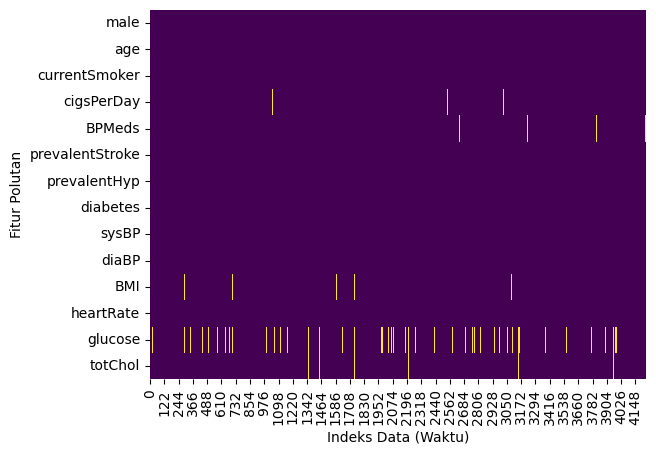

In [5]:
missing_value = pd.concat([df.isnull().sum(),
                           df.isnull().mean() * 100],
                          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
print(missing_value)

# plot
sns.heatmap(df.isnull().T, cbar=False, cmap='viridis')
plt.xlabel('Indeks Data (Waktu)')
plt.ylabel('Fitur Polutan')
plt.show()

In [6]:
df.duplicated().sum()

np.int64(0)

**Key insights**:
- Kolom `cigsPerDay`, `totChol`, `BPMeds`, `BMI`, `heartRate`, dan`glucose` memiliki missing value yang kurang dari 10% sehingga akan ditangani pada bagian Data Cleaning. 
- Khusus untuk `totChol`, penanganan akan dilakukan dengan drop row (dropna()) karena kolom ini merupakan target utama dalam analisis.
- Tidak ada data yang terduplikasi.

### Cek inconsistent value & outlier

In [7]:
# cek seberapa banyak nilai kolesterol ekstrem
totChol_ekstrem = df.loc[df['totChol'] > 400]
print(f"Jumlah baris dengan totChol ekstrem (>400): {totChol_ekstrem.shape[0]}")
totChol_ekstrem

Jumlah baris dengan totChol ekstrem (>400): 10


,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,totChol
194,0,42,0,0.0,0.0,0,0,0,128.0,87.0,22.90,72.0,72.0,464.0
543,1,47,1,18.0,0.0,0,1,0,145.0,74.0,22.42,100.0,90.0,439.0
1111,0,52,0,0.0,0.0,0,1,1,159.5,94.0,28.27,78.0,140.0,600.0
1544,1,42,1,20.0,0.0,0,0,0,116.0,83.0,21.68,90.0,83.0,410.0
1937,0,59,0,0.0,0.0,0,1,0,142.0,79.0,25.58,78.0,90.0,410.0
2206,1,46,1,15.0,0.0,0,1,0,181.5,102.5,26.33,98.0,97.0,405.0
2985,0,57,0,0.0,1.0,0,1,0,153.0,85.0,26.13,98.0,75.0,432.0
3160,1,51,1,9.0,0.0,0,1,0,157.0,87.0,24.44,95.0,84.0,696.0
3474,1,42,1,15.0,0.0,0,1,0,158.0,108.0,28.89,90.0,110.0,453.0
3806,0,52,1,20.0,0.0,0,0,0,105.0,67.5,27.33,75.0,90.0,410.0


In [8]:
# cek apakah ada data non-perokok dengan cigsPerDay lebih dari 0 dan sebaliknya
status_perokok = df[
    ((df['cigsPerDay'].fillna(0) > 0) & (df['currentSmoker'] == 0)) | # non-perokok cigPerDay > 0
    ((df['cigsPerDay'].fillna(0) == 0) & (df['currentSmoker'] == 1)) # perokok cigPerday = 0
]
print(f"Jumlah inkonsistensi status_perokok: {status_perokok.shape[0]}")
status_perokok

Jumlah inkonsistensi status_perokok: 29


,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,totChol
131,1,43,1,NaN,0.0,0,0,0,109.5,69.0,25.50,75.0,NaN,222.0
139,1,49,1,NaN,0.0,0,0,0,127.5,81.5,28.21,93.0,85.0,256.0
1046,0,49,1,NaN,0.0,0,0,0,120.0,80.0,22.33,90.0,75.0,280.0
1292,1,42,1,NaN,0.0,0,0,0,122.5,80.0,25.54,90.0,90.0,225.0
1347,0,58,1,NaN,0.0,0,1,0,195.0,117.5,23.35,75.0,NaN,270.0
1451,1,54,1,NaN,0.0,0,0,0,110.0,72.0,26.05,95.0,86.0,219.0
1497,1,55,1,NaN,0.0,0,0,0,132.5,85.5,29.25,70.0,103.0,214.0
1610,0,61,1,NaN,0.0,0,1,0,168.0,98.0,27.30,103.0,106.0,356.0
1625,0,49,1,NaN,0.0,0,1,0,158.0,102.0,25.31,90.0,72.0,233.0
1870,0,47,1,NaN,0.0,0,0,0,127.0,76.0,24.44,72.0,80.0,365.0


In [9]:
# cek apakah ada pasien yang tidak punya riwayat hipertensi (prevalentHyp==0) tapi minum obat tekanan darah (BPMeds==1)
status_hipertensi = df[
    (df['BPMeds'] == 1) &
    (df['prevalentHyp'] == 0)
]
print(f"Jumlah inkonsistensi status_hipertensi: {status_hipertensi.shape[0]}")
status_hipertensi

Jumlah inkonsistensi status_hipertensi: 0


,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,totChol


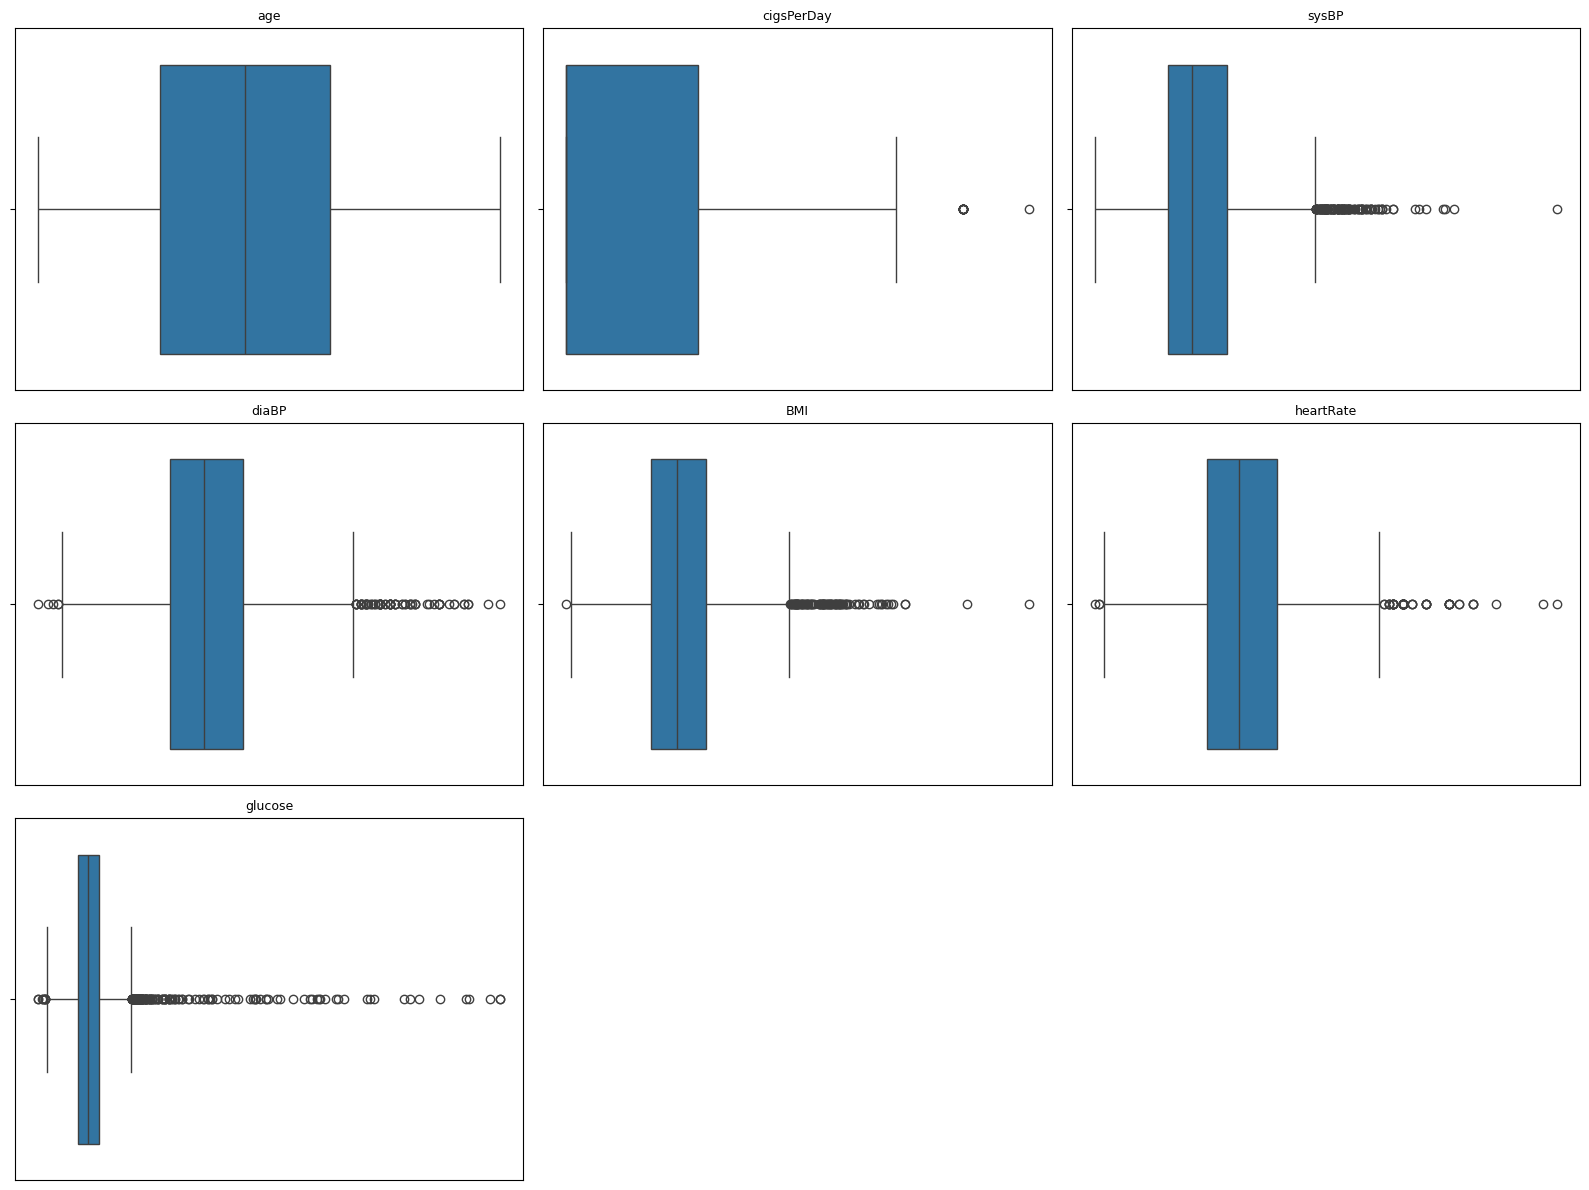

In [10]:
num_cek_outlier = ['age', 'cigsPerDay', 'sysBP','diaBP', 'BMI', 'heartRate', 'glucose']
n_rows = math.ceil(len(num_cek_outlier) / 3)

fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cek_outlier):
    sns.boxplot(x=df[col].dropna(), ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])
    axes[i].set_xlabel("")

# hapus subplot kosong kalau ada
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Key Insights**:
- Terdapat 10  baris data dengan nilai `totChol` tidak masuk akal (> 400) sehingga baris-baris data ini akan dihapus dari dataframe karena dianggap outlier yang dapat mengganggu hasil analisis.
- Terdapat 29 baris data dengan inconsistent value pada status perokok yang disebabkan karena missing value. Masalah ini akan ditangani bersamaan dengan penanganan missing value dengan imputasi mean untuk kolom `cigsPerDay`. Karena rentang mean `cigsPerDay` = 9.0, maka dapat dipastikan tidak akan ada masalah di mana ada pasien dengan status nonperokok yang merokok lebih dari 1 batang per hari karena baris yang bermasalah dan akan diimputasi ialah baris pasien dengan status perokok.
- Tidak terdapat inconsistent value pada `BPMeds` vs `prevalentHyp` (pasien dengan status tidak punya riwayat hipertensi (prevalentHyp==0) tapi minum obat tekanan darah (BPMeds==1))
- Kolom `cigsPerDay`, `sysBP`, `diaBP`, `BMI`, `heartRate`, dan `glucose` memiliki cukup banyak nilai outlier yang perlu ditangani pada tahap data cleaning.

## Data Cleaning

#### Outliers

In [11]:
df.loc[df['totChol'] > 400, 'totChol'] = np.nan

In [12]:
outliers_feat = ['sysBP', 'diaBP', 'BMI', 'heartRate', 'cigsPerDay', 'glucose']

for col in outliers_feat:
    df[col] = df[col].clip(
        lower=df[col].quantile(0.05),
        upper=df[col].quantile(0.95)
    )

df.describe()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,totChol
count,4240.000000,4240.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4180.000000
mean,0.429245,49.580189,0.494104,8.488008,0.029615,0.005896,0.310613,0.025708,131.763915,82.704316,25.678517,75.786506,80.015278,236.136842
std,0.495027,8.572942,0.500024,10.600409,0.169544,0.076569,0.462799,0.158280,19.406113,10.461686,3.474652,10.690129,12.172159,42.894562
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,104.000000,66.000000,20.060000,60.000000,62.000000,107.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,117.000000,75.000000,23.070000,68.000000,71.000000,206.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,128.000000,82.000000,25.400000,75.000000,78.000000,234.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,144.000000,90.000000,28.040000,83.000000,87.000000,263.000000
max,1.000000,70.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1.000000,175.000000,104.525000,32.780000,98.000000,108.450000,398.000000


#### Missing Value

In [13]:
cat_feat = [
    'male', 
    'currentSmoker', 
    'BPMeds',
    'prevalentStroke', 
    'prevalentHyp', 
    'diabetes',
]

num_feat = [
    'age', 
    'cigsPerDay', 
    'sysBP',
    'diaBP', 
    'BMI', 
    'heartRate', 
    'glucose'
]

In [14]:
# target missing = drop row
df = df.dropna(subset=['totChol'])

# feature missing = imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_feat] = cat_imputer.fit_transform(df[cat_feat])

num_imputer = SimpleImputer(strategy='mean')
df[num_feat] = num_imputer.fit_transform(df[num_feat])

df.isna().sum()

male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
totChol            0
dtype: int64

# Exploratory Data Analysis (EDA)

**Mendefinisikan Pertanyaan Bisnis**:
1. Seberapa banyak pasien dalam dataset ini yang memiliki kolesterol tinggi?
2. Bagaimana perbedaan risiko kolesterol antara laki-laki dan perempuan?
3. Apakah kelompok usia tertentu lebih rentan kolesterol tinggi?
4. Apakah hipertensi dan obesitas memperburuk risiko kolesterol tinggi?
5. Bagaimana perbedaan risiko kolesterol antara perokok dan non-perokok?
6. Faktor apa saja yang paling kuat berhubungan dengan total kolesterol dan seberapa besar kekuatannya?

## Data Overview

In [15]:
df_eda = df.copy()
df_eda.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,totChol
0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,106.0,70.0,26.97,80.0,77.0,195.0
1,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,121.0,81.0,28.73,95.0,76.0,250.0
2,1.0,48.0,1.0,20.0,0.0,0.0,0.0,0.0,127.5,80.0,25.34,75.0,70.0,245.0
3,0.0,61.0,1.0,30.0,0.0,0.0,1.0,0.0,150.0,95.0,28.58,65.0,103.0,225.0
4,0.0,46.0,1.0,23.0,0.0,0.0,0.0,0.0,130.0,84.0,23.10,85.0,85.0,285.0


## Struktur Data

In [16]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4180 entries, 0 to 4239
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4180 non-null   float64
 1   age              4180 non-null   float64
 2   currentSmoker    4180 non-null   float64
 3   cigsPerDay       4180 non-null   float64
 4   BPMeds           4180 non-null   float64
 5   prevalentStroke  4180 non-null   float64
 6   prevalentHyp     4180 non-null   float64
 7   diabetes         4180 non-null   float64
 8   sysBP            4180 non-null   float64
 9   diaBP            4180 non-null   float64
 10  BMI              4180 non-null   float64
 11  heartRate        4180 non-null   float64
 12  glucose          4180 non-null   float64
 13  totChol          4180 non-null   float64
dtypes: float64(14)
memory usage: 489.8 KB


**Key insights**:
- Tidak terdapat missing value
- Semua tipe kolom sudah sesuai dengan fitur-fitur kategorik sudah dalam bentuk encode.
- Setelah dibersihkan, jumlah baris data menjadi 4180 dari yang sebelumnya 4240 karena 60 baris missing value dari variabel target (`totChol`) dibuang (dropna()).
- Data sudah bersih dan siap dianalisis.

## Identifikasi Variabel

In [17]:
df_eda.describe()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,totChol
count,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000,4180.000000
mean,0.432536,49.558852,0.492344,8.455794,0.028708,0.005981,0.309809,0.025598,131.706699,82.693457,25.671543,75.732711,79.966871,236.136842
std,0.495487,8.568133,0.500001,10.554201,0.167005,0.077114,0.462470,0.157952,19.380190,10.439671,3.465105,10.679772,11.632616,42.894562
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,104.000000,66.000000,20.060000,60.000000,62.000000,107.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,117.000000,75.000000,23.070000,68.000000,72.000000,206.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,128.000000,82.000000,25.400000,75.000000,79.000000,234.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,143.500000,89.500000,27.992500,83.000000,85.000000,263.000000
max,1.000000,70.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1.000000,175.000000,104.525000,32.780000,98.000000,108.450000,398.000000


**Key insights**:
- Rata-rata `age` 49.56 tahun dengan standar deviasi 8.57 tahun dan rentang usia 32 hingga 70 tahun.
- Proporsi responden laki-laki pada kolom `male` sebesar 43.25% yang berarti banyaknya responden laki-laki kurang dari banyaknya responden perempuan.
- Hampir 50% responden memiliki status merokok dengan rata-rata 8 batang per hari. Distribusi `cigsPerDay` sangat skewed dengan min = Q1 = Q2 = 0, Q3 = 20, maks = 30. Nilai Q2 (median) = 0 menunjukkan bahwa lebih dari separuh responden tidak merokok sama sekali.
- Tekanan darah sistolik pada kolom `sysBP` memiliki rata-rata 131.71 mmHg, sementara tekanan darah diastolik pada kolom `diaBP` memiliki rata-rata 82.69 mmHg.
- Prevalensi hipertensi (`prevalentHyp`) mencapai 30.98% dari total responden. Sementara itu, hanya 2.87% responden yang mengonsumsi obat tekanan darah (`BPMeds`), 2.56% menderita diabetes, dan 0.60% memiliki riwayat stroke.
- `BMI` rata-rata 25.67 menunjukkan populasi secara rata-rata berada di kategori overweight dengan rentang 20.06-32.78.
- `heartRate` rata-rata 75.73 bpm (normal), dengan rentang 60-98.
- `Glucose` rata-rata 79.97 mg/dL (normal), dengan nilai maks mencapai 108.45 mg/dL.
- Rata-rata nilai total kolesterol (`totChol`) adalah 236.14 mg/dL di mana ini termasuk kategori kolesterol tinggi (normal < 200).

## Distribusi Data

In [18]:
df_eda.nunique()

male                  2
age                  39
currentSmoker         2
cigsPerDay           26
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
sysBP               141
diaBP                79
BMI                1042
heartRate            40
glucose              49
totChol             240
dtype: int64

In [19]:
for col in cat_feat:
    print(f"Column: {col}")
    print(f"Number of unique values: {df_eda[col].nunique()}")

    print(pd.concat([df_eda[col].value_counts(),
                     df_eda[col].value_counts(normalize=True) * 100],
                     axis=1, keys=['Count', 'Percentage (%)']))
    print("\n")

Column: male
Number of unique values: 2
      Count  Percentage (%)
male                       
0.0    2372       56.746411
1.0    1808       43.253589


Column: currentSmoker
Number of unique values: 2
               Count  Percentage (%)
currentSmoker                       
0.0             2122        50.76555
1.0             2058        49.23445


Column: BPMeds
Number of unique values: 2
        Count  Percentage (%)
BPMeds                       
0.0      4060       97.129187
1.0       120        2.870813


Column: prevalentStroke
Number of unique values: 2
                 Count  Percentage (%)
prevalentStroke                       
0.0               4155       99.401914
1.0                 25        0.598086


Column: prevalentHyp
Number of unique values: 2
              Count  Percentage (%)
prevalentHyp                       
0.0            2885       69.019139
1.0            1295       30.980861


Column: diabetes
Number of unique values: 2
          Count  Percentage (%)
diab

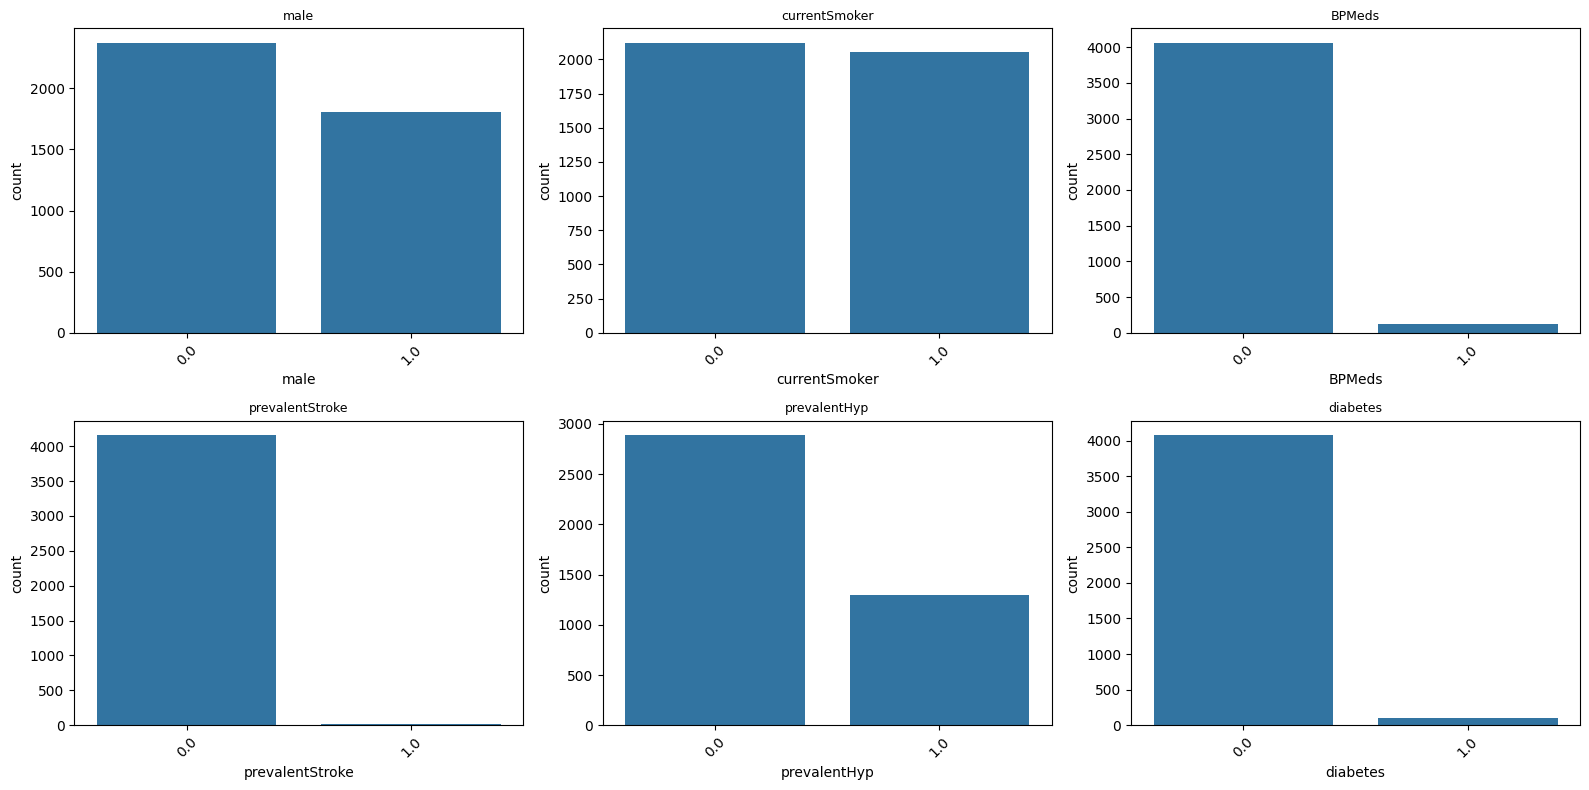

In [20]:
n_cols = 3
n_rows = math.ceil(len(cat_feat) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_feat):
    sns.countplot(x=col, data=df_eda, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', rotation=45)

# hapus subplot kosong kalau ada
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Key Insights**:
- Distribusi gender menunjukkan bahwa responden perempuan (0) lebih banyak daripada laki-laki, yaitu 2372 (56.75%) vs 1808 (43.25%)
- Distribusi perokok dan non-perokok pada `currentSmoker` relatif seimbang (hampir sama dengan 50.76% vs 49.23%).
- Distribusi `BPMeds`sangat imbalance dengan mayoritas responden tidak mengonsumsi obat, yaitu sebanyak 4060 atau 97%.
- Hampir seluruh responden tidak memiliki riwayat stroke (99%) dan diabetes (97%).
- Distribusi `prevalentHyp` menunjukkan bahwa responden tanpa riwayat hipertensi sebanyak 2885 atau 69%, lebih banyak daripada responden dengan riwayat hipertensi.

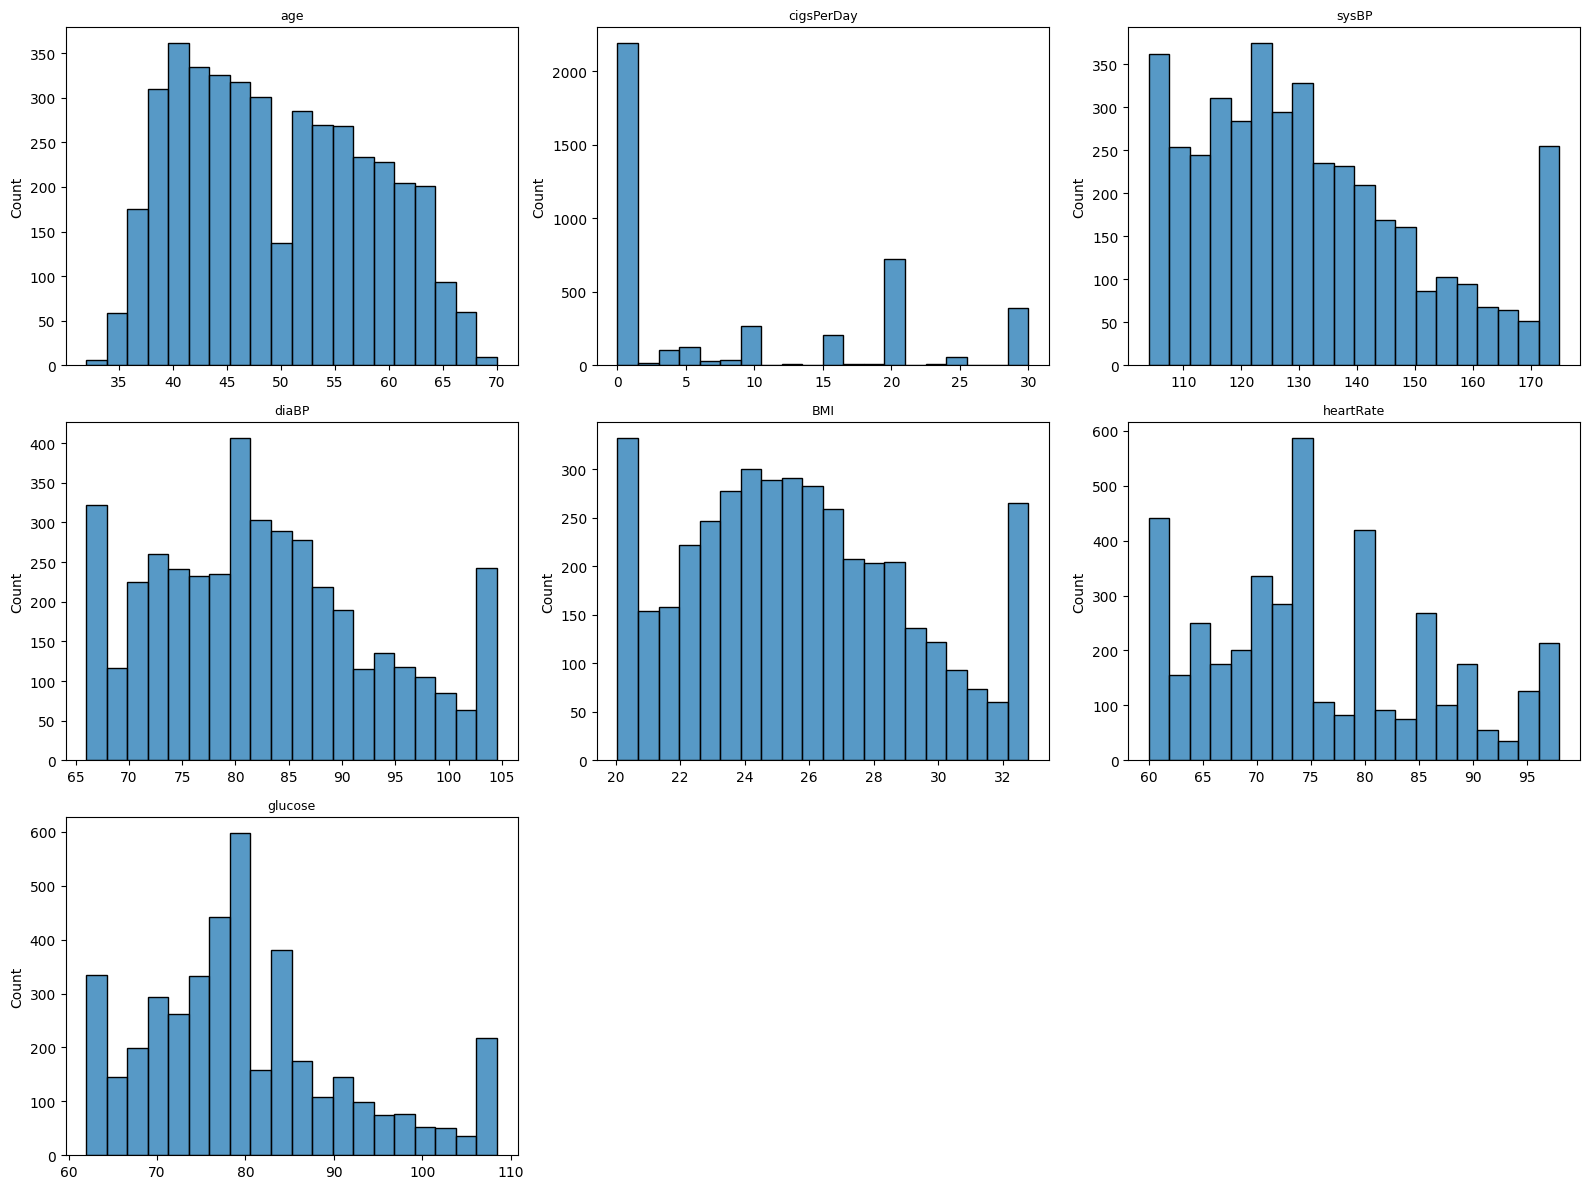

In [21]:
n_cols = 3
n_rows = math.ceil(len(num_feat) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_feat):
    sns.histplot(df_eda[col], bins=20, kde=False, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

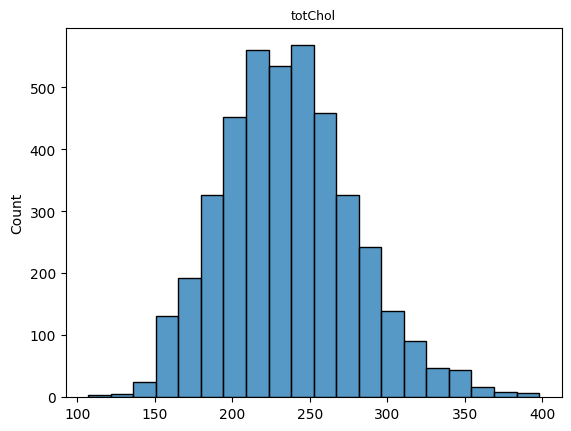

In [22]:
sns.histplot(df_eda["totChol"], bins=20, kde=False)
plt.title("totChol", fontsize=9)
plt.xlabel("")
plt.show()

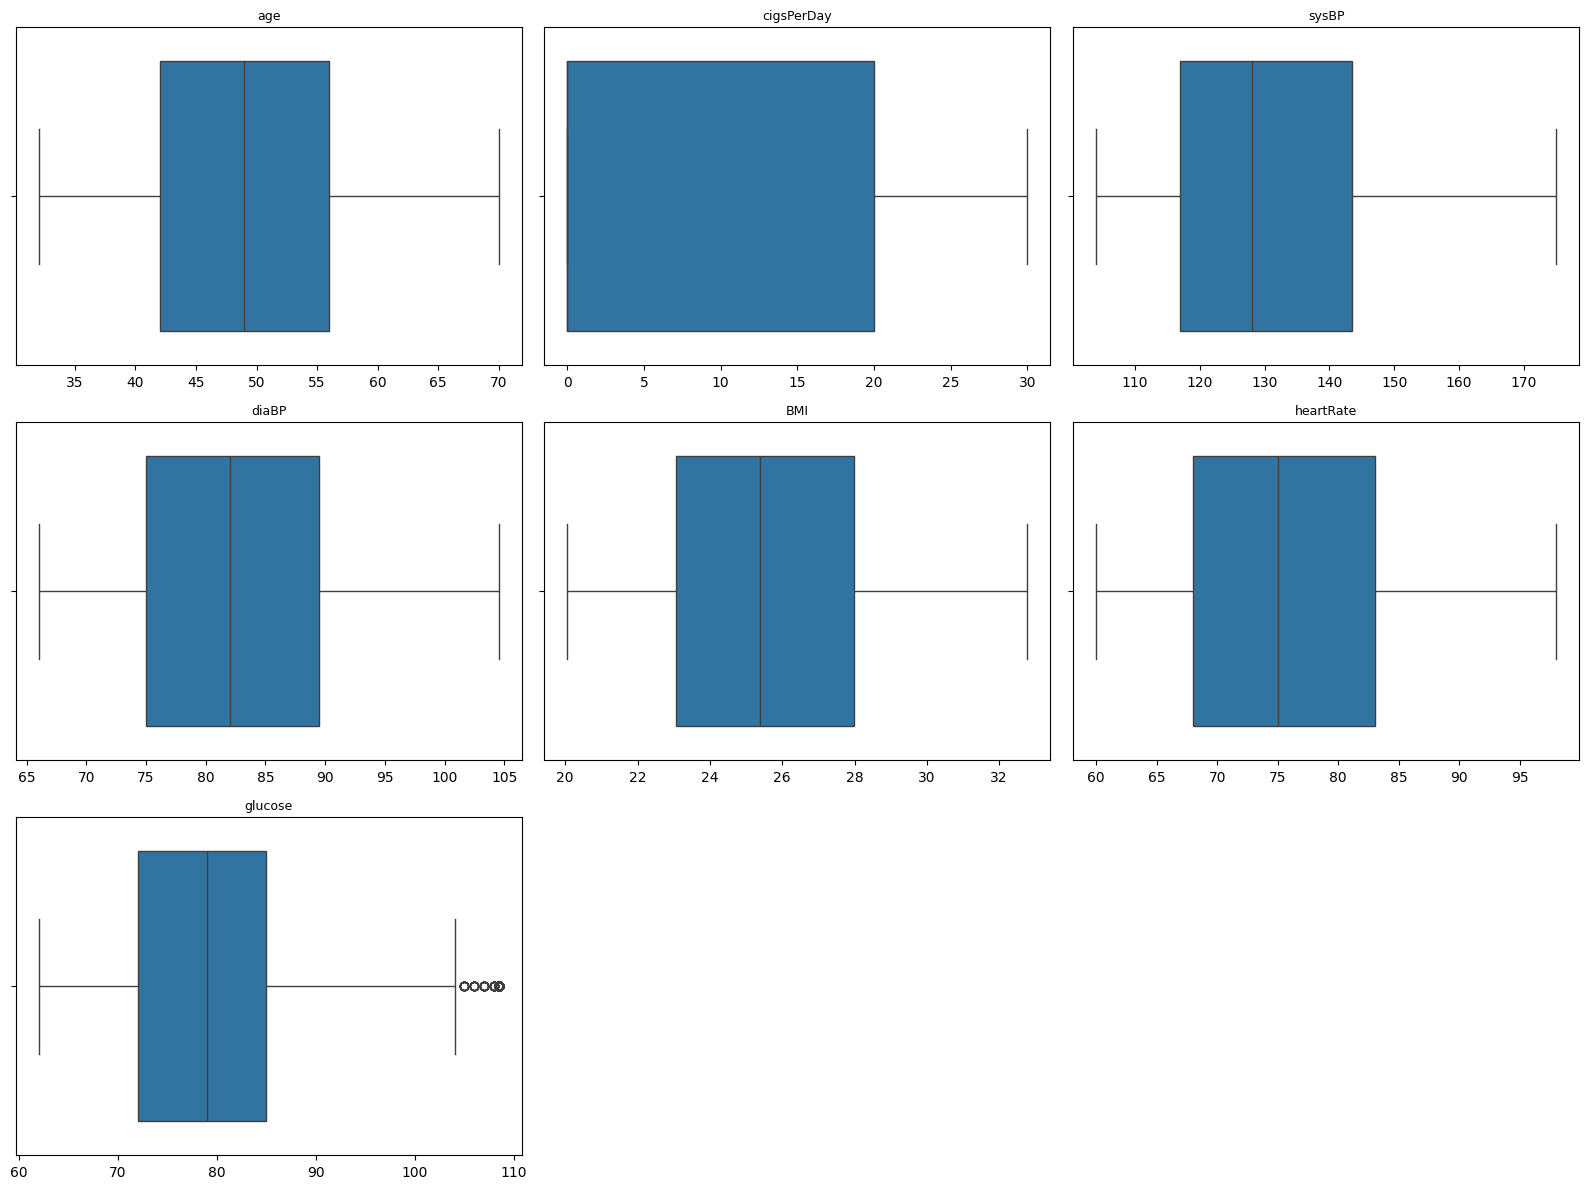

In [23]:
n_cols = 3
n_rows = math.ceil(len(num_feat) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_feat):
    sns.boxplot(x=df_eda[col], ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Key Insights**:
- Distribusi `age` menunjukkan pola yang condong ke kanan (right-skewed) dengan puncak distribusi berada di sekitar usia 40 tahun. Boxplot `age` relatif simetris dengan median sekitar 49 tahun.
- `cigsPerDay` menunjukkan distribusi yang sangat right-skewed dengan sebagian besar data bertumpuk pada nilai 0. Pola ini juga terlihat pada boxplot dengan IQR berada antara 0-20 batang per hari.
- `sysBP`, `diaBP`, dan `heartRate` menunjukkan pola yang mirip dengan distribusi  yang agak right-skewed.
- Distribusi `BMI` hampir mendekati normal dengan puncak di sekitar 24-26. Boxplot `BMI` juga terlihat cukup simetris yang menunjukkan bahwa sebara BMI dalam dataset ini relatif homogen.
- `totChol` menunjukkan distribusi yang mendekati simetris dan berbentuk normal dengan puncak berada di 210-250 mg/dL.

## Korelasi

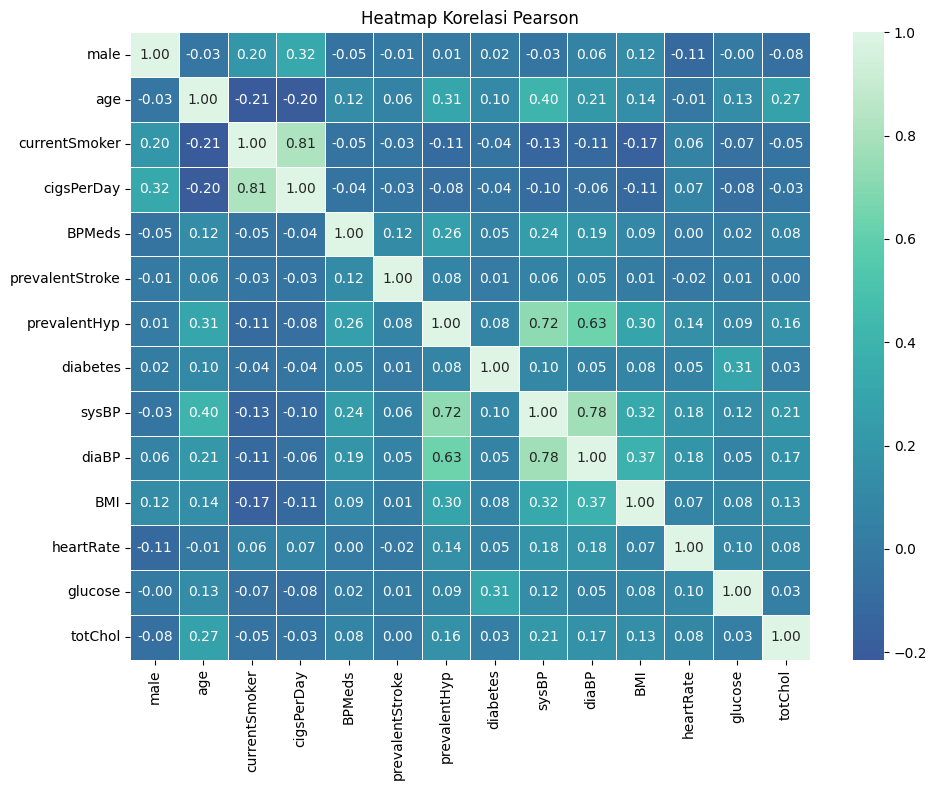

In [24]:
correlation = df_eda.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="mako",
    center=0,
    linewidth=0.5
)

plt.title("Heatmap Korelasi Pearson")
plt.tight_layout()
plt.show()

**Key Insights**:
- Variabel yang berkorelasi positif terhadap total kolesterol  (`totChol`), yaitu `prevalentHyp`, `age`, `sysBP`, `diaBP`, `BMI`, dan `heartRate` dengan variabel `age` memiliki tingkat korelasi paling tinggi, yaitu 0.27. Meskipun demikian, nilai ini menunjukkan hubungan yang lemah-sedang.
- Sementara itu, variabel yang berkolerasi negatif terhadap total kolesterol (`totChol`), yaitu gender (`male`), `currentSmoker`, `cigsPerDay`, `glucose`, dan `diabetes` dengan variabel gender menunjukkan tingkat korelasi paling tinggi, yaitu -0.08 yang termasuk hubungan sangat lemah.
- Tidak ada variabel yang berkorelasi kuat dengan `totChol` yang ditunjukkan oleh nilai r < 0.30 untuk semua variabel pada dataset ini jika dilihat dari hubungan linier antarvariabel-nya (Pearson Correlation).
- Feature engineering perlu dilakukan untuk membuat fitur-fitur yang lebih dapat menjelaskan variabel target, yaitu `totChol`.

# Feature Engineering

In [25]:
def feat_eng(df):
    df['pulse_pressure'] = df['sysBP'] - df['diaBP']

    df['bp_ratio'] = df['sysBP'] / df['diaBP']

    df['age_group'] = pd.cut(
        df['age'],
        bins=[0,34,55,99],
        labels=['< 35', '35-55', '> 55']
    )

    df['bmi_category'] = pd.cut(
        df['BMI'],
        bins=[0, 18.5, 25.0, 30.0, 999],
        labels=['Underweight', 'Normal', 'Overweight', 'Obese']
    )

    df['smoking_intensity'] = pd.cut(
        df['cigsPerDay'],
        bins=[-1, 0, 10, 20, 999],
        labels=['None', 'Light', 'Moderate', 'Heavy']
    )

    df['glucose_risk'] = pd.cut(
        df['glucose'],
        bins=[0, 99, 125, 999],
        labels=['Normal', 'Prediabetes', 'Diabetes']
    )
    
    df['highBP'] = (
        (df['sysBP'] >= 140) |
        (df['diaBP'] >= 90)
    ).astype(int)

    df['hyp_x_diabetes'] = (
        df['prevalentHyp'].astype(int) * df['diabetes'].astype(int)
    )

    # Smoker × Age: risiko merokok makin besar seiring usia
    df['smoker_x_age'] = (
        df['currentSmoker'].astype(int) * df['age']
    )

    # Obese × Hypertension: kombinasi kardiovaskular klasik
    df['obese_x_hyp'] = (
        (df['BMI'] > 30).astype(int) * df['prevalentHyp'].astype(int)
    )
    
    return df

In [26]:
df_eda = feat_eng(df_eda)
print(df_eda.info())
df_eda.head()

<class 'pandas.core.frame.DataFrame'>
Index: 4180 entries, 0 to 4239
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   male               4180 non-null   float64 
 1   age                4180 non-null   float64 
 2   currentSmoker      4180 non-null   float64 
 3   cigsPerDay         4180 non-null   float64 
 4   BPMeds             4180 non-null   float64 
 5   prevalentStroke    4180 non-null   float64 
 6   prevalentHyp       4180 non-null   float64 
 7   diabetes           4180 non-null   float64 
 8   sysBP              4180 non-null   float64 
 9   diaBP              4180 non-null   float64 
 10  BMI                4180 non-null   float64 
 11  heartRate          4180 non-null   float64 
 12  glucose            4180 non-null   float64 
 13  totChol            4180 non-null   float64 
 14  pulse_pressure     4180 non-null   float64 
 15  bp_ratio           4180 non-null   float64 
 16  age_group  

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,...,pulse_pressure,bp_ratio,age_group,bmi_category,smoking_intensity,glucose_risk,highBP,hyp_x_diabetes,smoker_x_age,obese_x_hyp
0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,106.0,70.0,...,36.0,1.514286,35-55,Overweight,None,Normal,0,0,0.0,0
1,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,121.0,81.0,...,40.0,1.493827,35-55,Overweight,None,Normal,0,0,0.0,0
2,1.0,48.0,1.0,20.0,0.0,0.0,0.0,0.0,127.5,80.0,...,47.5,1.593750,35-55,Overweight,Moderate,Normal,0,0,48.0,0
3,0.0,61.0,1.0,30.0,0.0,0.0,1.0,0.0,150.0,95.0,...,55.0,1.578947,> 55,Overweight,Heavy,Prediabetes,1,0,61.0,0
4,0.0,46.0,1.0,23.0,0.0,0.0,0.0,0.0,130.0,84.0,...,46.0,1.547619,35-55,Normal,Heavy,Normal,0,0,46.0,0


#### Binning totChol
Threshold:
- normal: < 200
- berisiko: 200-239
- kolesterol: >= 240

In [27]:
bins = [0, 200, 240, np.inf]

labels = [
    'Normal', 
    'Berisiko', 
    'Kolesterol'
]

df_eda['catChol'] = pd.cut(
    df_eda['totChol'],
    bins=bins, labels=labels, right=True
)
df_eda.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,...,bp_ratio,age_group,bmi_category,smoking_intensity,glucose_risk,highBP,hyp_x_diabetes,smoker_x_age,obese_x_hyp,catChol
0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,106.0,70.0,...,1.514286,35-55,Overweight,None,Normal,0,0,0.0,0,Normal
1,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,121.0,81.0,...,1.493827,35-55,Overweight,None,Normal,0,0,0.0,0,Kolesterol
2,1.0,48.0,1.0,20.0,0.0,0.0,0.0,0.0,127.5,80.0,...,1.593750,35-55,Overweight,Moderate,Normal,0,0,48.0,0,Kolesterol
3,0.0,61.0,1.0,30.0,0.0,0.0,1.0,0.0,150.0,95.0,...,1.578947,> 55,Overweight,Heavy,Prediabetes,1,0,61.0,0,Berisiko
4,0.0,46.0,1.0,23.0,0.0,0.0,0.0,0.0,130.0,84.0,...,1.547619,35-55,Normal,Heavy,Normal,0,0,46.0,0,Kolesterol


# Explanatory Analysis


**Pertanyaan Bisnis**:
1. Seberapa banyak pasien dalam dataset ini yang memiliki kolesterol tinggi?
2. Bagaimana perbedaan risiko kolesterol antara laki-laki dan perempuan?
3. Apakah kelompok usia tertentu lebih rentan kolesterol tinggi?
4. Apakah hipertensi dan obesitas memperburuk risiko kolesterol tinggi?
5. Bagaimana perbedaan risiko kolesterol antara perokok dan non-perokok?
6. Faktor apa saja yang paling kuat berhubungan dengan total kolesterol dan seberapa besar kekuatannya?

In [28]:
df = df_eda.copy()
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,...,bp_ratio,age_group,bmi_category,smoking_intensity,glucose_risk,highBP,hyp_x_diabetes,smoker_x_age,obese_x_hyp,catChol
0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,106.0,70.0,...,1.514286,35-55,Overweight,None,Normal,0,0,0.0,0,Normal
1,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,121.0,81.0,...,1.493827,35-55,Overweight,None,Normal,0,0,0.0,0,Kolesterol
2,1.0,48.0,1.0,20.0,0.0,0.0,0.0,0.0,127.5,80.0,...,1.593750,35-55,Overweight,Moderate,Normal,0,0,48.0,0,Kolesterol
3,0.0,61.0,1.0,30.0,0.0,0.0,1.0,0.0,150.0,95.0,...,1.578947,> 55,Overweight,Heavy,Prediabetes,1,0,61.0,0,Berisiko
4,0.0,46.0,1.0,23.0,0.0,0.0,0.0,0.0,130.0,84.0,...,1.547619,35-55,Normal,Heavy,Normal,0,0,46.0,0,Kolesterol


In [29]:
palette_3 = ['#22C55E', '#F59E0B', '#EF4444']
palette_2 = ['#F58518', '#4C78A8']
cat_order = ['Normal', 'Berisiko', 'Kolesterol']
ALPHA = 0.05

## PB 1: Seberapa banyak pasien dengan kolesterol tinggi?

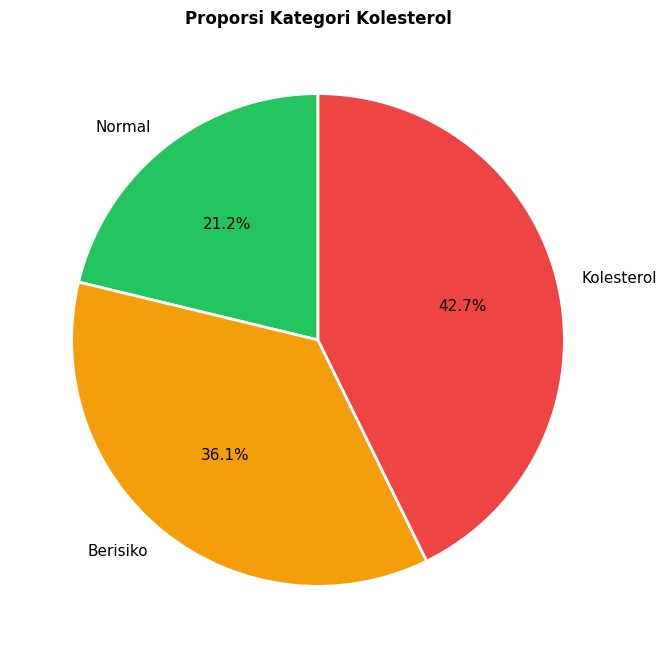

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 8))

counts = df["catChol"].value_counts().reindex(cat_order)
tick_labels = ["Normal", "Berisiko", "Kolesterol"]

wedges, texts, autotexts = ax1.pie(
    counts, 
    labels=tick_labels, 
    colors=palette_3,
    autopct="%1.1f%%", 
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops={"fontsize": 11}
)

ax1.set_title("Proporsi Kategori Kolesterol", fontweight="bold")
plt.show()

In [31]:
# Distribusi Kategori Kolesterol
df['catChol'].value_counts()

catChol
Kolesterol    1786
Berisiko      1507
Normal         887
Name: count, dtype: int64

**Key insights**:
- Dari pie chart di atas, kategori terbanyak adalah `kolesterol` yaitu 42.7% atau sebanyak 1786 orang, diikuti oleh kategori `berisiko` 36.1% atau 1507 orang, dan `normal` 21.2% atau 887 orang.

## PB 2: Bagaimana perbedaan risiko kolesterol antara laki-laki dan perempuan?

In [32]:
pivot_gender = (
    df.groupby("catChol")["male"]
    .value_counts()
    .rename("Proporsi (%)")
    .reset_index()
)

pivot_gender["Gender"] = pivot_gender["male"].map({0: "Perempuan", 1: "Laki-laki"})
pivot_tbl = pivot_gender.pivot(
    index="Gender", 
    columns="catChol", 
    values="Proporsi (%)"
).reindex(columns=cat_order).round(2)

pivot_tbl.columns = ["Normal", "Berisiko", "Kolesterol"]
pivot_tbl

,Normal,Berisiko,Kolesterol
Gender,,,
Laki-laki,384,723,701
Perempuan,503,784,1085


In [33]:
pivot_gender = (
    df.groupby("male")["catChol"]
    .value_counts(normalize=True)
    .mul(100).rename("Proporsi (%)")
    .reset_index()
)

pivot_gender["Gender"] = pivot_gender["male"].map({0: "Perempuan", 1: "Laki-laki"})
pivot_tbl_prop = pivot_gender.pivot(
    index="Gender", 
    columns="catChol", 
    values="Proporsi (%)"
).reindex(columns=cat_order).round(2)

pivot_tbl_prop.columns = ["Normal (%)", "Berisiko (%)", "Kolesterol (%)"]
pivot_tbl_prop

,Normal (%),Berisiko (%),Kolesterol (%)
Gender,,,
Laki-laki,21.24,39.99,38.77
Perempuan,21.21,33.05,45.74


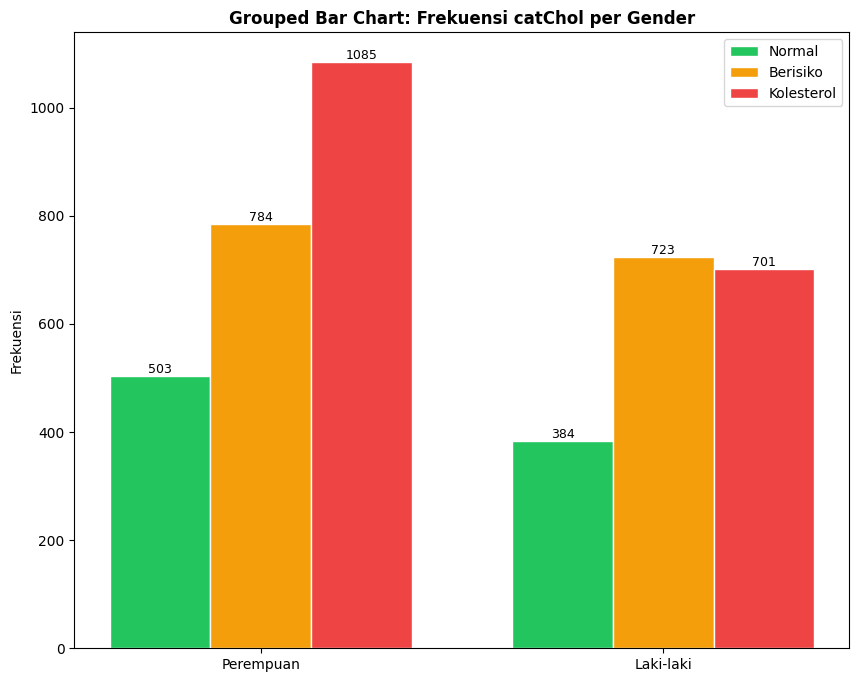

In [34]:
fig, ax1 = plt.subplots(figsize=(10, 8))

x      = np.arange(2)
width  = 0.25
genders = ["Perempuan", "Laki-laki"]
for i, (cat, tick_label, color) in enumerate(zip(cat_order, 
                                          ["Normal", "Berisiko", "Kolesterol"], 
                                          palette_3)):
    col_name = tick_label
    bar_vals = [pivot_tbl.loc[g, col_name] for g in genders]
    bars = ax1.bar(x + (i-1)*width, bar_vals, width,
                   label=tick_label, color=color, edgecolor="white")
    for bar in bars:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(genders)
ax1.set_ylabel("Frekuensi")
ax1.set_title("Grouped Bar Chart: Frekuensi catChol per Gender", fontweight="bold")
ax1.legend()
plt.show()

**Key insights**:
- Perempuan
    - mayoritas berada di kateogri kolesterol (1085 atau 45.74%)
    - distribusi cenderung ke risiko kolesterol tinggi
- Laki laki
    - kategori berisiko (39.99%) dan kolesterol tinggi (38.77%) hampir seimbang
    - pola lebih merata dibanding perempuan

Untuk memastikan apakah benar-benar ada perbedaan signifikan secara statistik antara dua kelompok gender terhadap kolesterol, akan dilakukan A/B Testing.

### A/B Testing - Kelompok Gender: Laki-laki vs Perempuan

A/B testing dilakukand dengan taraf signifikansi α = 0.05, dengan hipotesis sebagai berikut.

HIPOTESIS: <br>
  H₀ : μ__perempuan = μ__laki-laki <br>
       (tidak ada perbedaan rata-rata totChol antar gender) <br>
  H₁ : μ__perempuan ≠ μ__laki-laki <br>
       (ada perbedaan rata-rata totChol antar gender) <br>
  α  : 0.05 (two-tailed) <br>

Metode pengujian yang dilakukan sangat bergantung pada distribusi data. 
- Jika data berdistribusi normal, maka dapat menggunakan statistika parametrik. Kemudian jika varians data sama, maka dapat menggunakan t-test, jika berbeda dapat menggunakan welch's t-test.
- Jika data tidak berdistribusi normal, maka dapat menggunakan statistika non-parametrik dengan metode Mann-Whitney U.

In [35]:
# helpers
def cek_normalitas(data, label, alpha=ALPHA):
    """Shapiro-Wilk jika n<=5000, else Kolmogorov-Smirnov"""
    if len(data) <= 5000:
        stat, p = shapiro(data)
        test_name = "Shapiro-Wilk"
    else:
        stat, p = stats.kstest(data, "norm",
                               args=(data.mean(), data.std()))
        test_name = "Kolmogorov-Smirnov"
    normal = p > alpha # normal jika pvalue > alpha 0.05
    print(f"  [{label}] {test_name}: stat={stat:.4f}, p={p:.4f} "
          f"→ {'NORMAL ✅' if normal else 'TIDAK NORMAL ❌'}")
    return normal

def cek_levene(*groups, alpha=ALPHA):
    """Levene's test untuk homogenitas varians"""
    stat, p = levene(*groups)
    sama = p > alpha # # homogen (varians sama) jika pvalue > alpha 0.05
    print(f"  Levene's Test: stat={stat:.4f}, p={p:.4f} "
          f"→ Varians {'SAMA ✅' if sama else 'BERBEDA ❌'}")
    return sama

def print_keputusan(p, alpha=ALPHA, h0="H₀", h1="H₁"):
    print(f"\n  {'='*50}")
    print(f"  p-value  : {p:.4f}")
    print(f"  α        : {alpha}")
    if p < alpha: # signifikan jika pvalue < alpha 0.05
        print(f"  Keputusan: TOLAK {h0}")
        print(f"  Kesimpulan: {h1} diterima ✅")
    else:
        print(f"  Keputusan: GAGAL TOLAK {h0}")
        print(f"  Kesimpulan: {h0} diterima ✅")
    print(f"  {'='*50}")

In [36]:
print("\n" + "="*60)
print("A/B TESTING: Perbedaan totChol antara Gender")
print("="*60)

print("""
HIPOTESIS:
  H₀ : μ_perempuan = μ_laki-laki
       (tidak ada perbedaan rata-rata totChol antar gender)
  H₁ : μ_perempuan ≠ μ_laki-laki
       (ada perbedaan rata-rata totChol antar gender)
  α  : 0.05 (two-tailed)
""")

# Data
perempuan = df[df["male"]==0]["totChol"].dropna()
laki_laki = df[df["male"]==1]["totChol"].dropna()

print(f"Statistik Deskriptif:")
print(f"  Perempuan : n={len(perempuan)}, mean={perempuan.mean():.2f}, std={perempuan.std():.2f}")
print(f"  Laki-laki : n={len(laki_laki)}, mean={laki_laki.mean():.2f}, std={laki_laki.std():.2f}")

# Cek asumsi
print(f"\nCEK ASUMSI:")
normal_p = cek_normalitas(perempuan, "Perempuan")
normal_l = cek_normalitas(laki_laki, "Laki-laki")
kedua_normal = normal_p and normal_l

if kedua_normal:
    varians_sama = cek_levene(perempuan, laki_laki)
else:
    varians_sama = None
    print("  (Skip Levene karena data tidak normal, lanjut non-parametrik)")


print(f"\nSTATISTIK UJI:")
if kedua_normal and varians_sama:
    test_name = "Independent t-test"
    stat, p   = ttest_ind(perempuan, laki_laki, equal_var=True)
    df_val    = len(perempuan) + len(laki_laki) - 2
    print(f"  Test dipilih : {test_name}")
    print(f"  t-statistic  : {stat:.4f}")
    print(f"  Degrees of Freedom : {df_val}")
    print(f"  Daerah Kritis: |t| > t_tabel(α/2, df={df_val})")
    print(f"  t_tabel      : ±{stats.t.ppf(1-ALPHA/2, df_val):.4f}")
    print(f"  |t_hitung|   : {abs(stat):.4f} "
          f"{'> t_tabel → TOLAK H₀' if abs(stat) > stats.t.ppf(1-ALPHA/2, df_val) else '< t_tabel → GAGAL TOLAK H₀'}")

elif kedua_normal and not varians_sama:
    test_name = "Welch's t-test"
    stat, p   = ttest_ind(perempuan, laki_laki, equal_var=False)
    print(f"  Test dipilih : {test_name}")
    print(f"  t-statistic  : {stat:.4f}")
    print(f"  Daerah Kritis: p-value < α={ALPHA}")

else:
    test_name = "Mann-Whitney U"
    stat, p   = mannwhitneyu(perempuan, laki_laki, alternative="two-sided")
    print(f"  Test dipilih : {test_name} (non-parametrik)")
    print(f"  U-statistic  : {stat:.4f}")
    print(f"  Daerah Kritis: p-value < α={ALPHA}")

print_keputusan(p,
    h0="H₀: μ_perempuan = μ_laki-laki",
    h1="H₁: Ada perbedaan rata-rata totChol antar gender")


A/B TESTING: Perbedaan totChol antara Gender

HIPOTESIS:
  H₀ : μ_perempuan = μ_laki-laki
       (tidak ada perbedaan rata-rata totChol antar gender)
  H₁ : μ_perempuan ≠ μ_laki-laki
       (ada perbedaan rata-rata totChol antar gender)
  α  : 0.05 (two-tailed)

Statistik Deskriptif:
  Perempuan : n=2372, mean=238.97, std=44.97
  Laki-laki : n=1808, mean=232.42, std=39.72

CEK ASUMSI:
  [Perempuan] Shapiro-Wilk: stat=0.9888, p=0.0000 → TIDAK NORMAL ❌
  [Laki-laki] Shapiro-Wilk: stat=0.9931, p=0.0000 → TIDAK NORMAL ❌
  (Skip Levene karena data tidak normal, lanjut non-parametrik)

STATISTIK UJI:
  Test dipilih : Mann-Whitney U (non-parametrik)
  U-statistic  : 2310258.5000
  Daerah Kritis: p-value < α=0.05

  p-value  : 0.0000
  α        : 0.05
  Keputusan: TOLAK H₀: μ_perempuan = μ_laki-laki
  Kesimpulan: H₁: Ada perbedaan rata-rata totChol antar gender diterima ✅


**Key insights**:
- Dari output di atas, diperoleh hasil bahwa ada perbedaan rata-rata totChol antara dua kelompok gender terhadap total kolesterol.

## PB 3: Apakah kelompok usia tertentu lebih rentan kolesterol tinggi?

In [37]:
pivot_age = (
    df.groupby("age_group")["catChol"]
    .value_counts(normalize=True)
    .mul(100).rename("Proporsi")
    .reset_index()
)

pivot_age["age_group"] = pd.Categorical(
    pivot_age["age_group"],
    categories=["< 35", "35-55", "> 55"],
    ordered=True
)

pivot_age_wide = (
    pivot_age
    .pivot(index="age_group", columns="catChol", values="Proporsi")
    .reindex(columns=cat_order)
    .fillna(0)
    .sort_index()
)
pivot_age_wide.columns = ["Normal", "Berisiko", "Kolesterol"]
pivot_age_wide

,Normal,Berisiko,Kolesterol
age_group,,,
< 35,66.666667,25.000000,8.333333
35-55,24.134487,37.816245,38.049268
> 55,12.673611,31.684028,55.642361


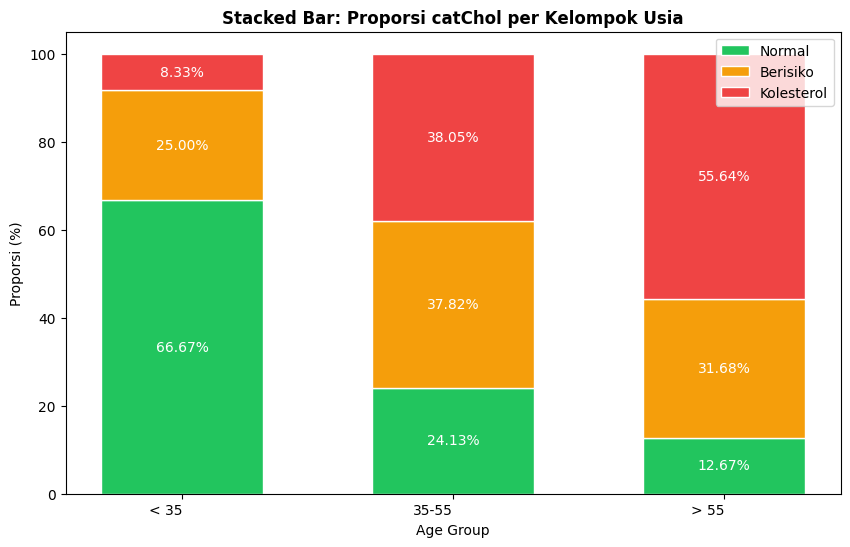

In [38]:
fig, ax1 = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(pivot_age_wide))
for col, color in zip(["Normal", "Berisiko", "Kolesterol"], palette_3):
    vals = pivot_age_wide[col].values
    bars = ax1.bar(
        pivot_age_wide.index.astype(str), 
        pivot_age_wide[col],
        bottom=bottom, 
        label=col, 
        color=color, 
        edgecolor="white", width=0.6
    )
    

    for bar, val, bot in zip(bars, vals, bottom):
        if val > 3:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bot + val / 2,
                f"{val:.2f}%",
                ha="center", va="center",
                fontsize=10, color="white"
            )
    
    bottom += vals

ax1.set_xlabel("Age Group"); ax1.set_ylabel("Proporsi (%)")
ax1.set_title("Stacked Bar: Proporsi catChol per Kelompok Usia", fontweight="bold")
plt.setp(ax1.get_xticklabels(), ha="right")
ax1.legend()
plt.show()

**Key insights**:
- Kelompok usia `< 35` yang berkategori `normal` sebesar 66.67% yang berarti kelompok usia ini yang paling sehat dibanding kelompok usia lainnya. Hanya 8.33% yang termasuk kategori `kolesterol` pada kelompok usia ini.
- Sementara itu, terjadi pergeseran signifikan pada kelompok usia `35-55` dengan proporsi `normal` turun signifikan menjadi 24.13%, `berisiko` meningkat menjadi 37.82%, dan `kolesterol` meningkat menjadi 38.05%.
- Pada kelompok usia `> 55`, sebagian besar pasien pada kelompok ini berada pada kategori `kolesterol` (55.64%) dan hanya 12.67% yang masih normal.

## PB 4: Apakah hipertensi dan obesitas memperburuk risiko kolesterol tinggi?

In [39]:
pivot_bp = (
    df.groupby("highBP")["catChol"]
    .value_counts(normalize=True)
    .mul(100).rename("Proporsi")
    .reset_index()
)
pivot_bp_wide = (
    pivot_bp
    .pivot(index="highBP", columns="catChol", values="Proporsi")
    .reindex(columns=cat_order)
    .fillna(0)
)
pivot_bp_wide.index   = ["Tanpa Hipertensi", "Hipertensi"]
pivot_bp_wide.columns = ["Normal", "Berisiko", "Kolesterol"]
pivot_bp_wide

,Normal,Berisiko,Kolesterol
Tanpa Hipertensi,24.767917,37.430375,37.801708
Hipertensi,14.794889,33.557498,51.647613


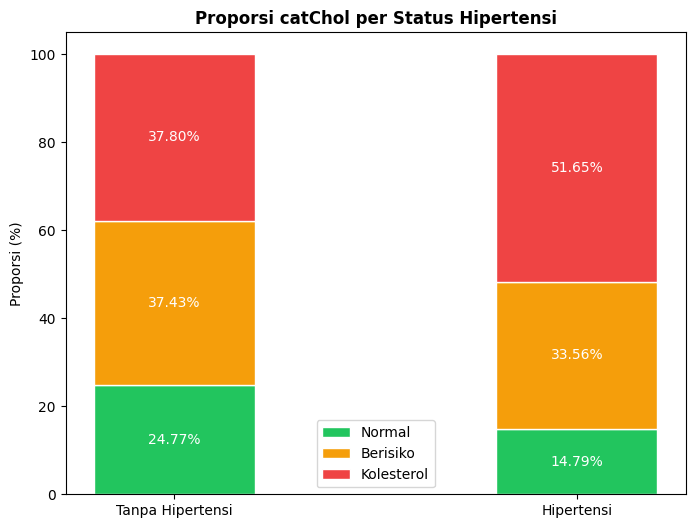

In [40]:
fig, ax1 = plt.subplots(figsize=(8, 6))

bottom = np.zeros(len(pivot_bp_wide))
for col, color in zip(["Normal", "Berisiko", "Kolesterol"], palette_3):
    vals = pivot_bp_wide[col].values
    bars = ax1.bar(
        pivot_bp_wide.index, 
        pivot_bp_wide[col],
        bottom=bottom, 
        label=col, 
        color=color, 
        edgecolor="white", 
        width=0.4
    )
    

    for bar, val, bot in zip(bars, vals, bottom):
        if val > 3:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bot + val / 2,
                f"{val:.2f}%",
                ha="center", va="center",
                fontsize=10, color="white"
            )
    
    bottom += vals

ax1.set_ylabel("Proporsi (%)")
ax1.set_title("Proporsi catChol per Status Hipertensi", fontweight="bold")
ax1.legend()
plt.show()

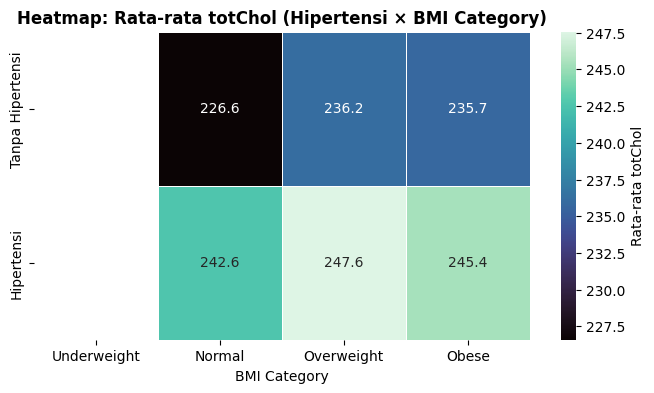

In [41]:
fig, ax2 = plt.subplots(figsize=(8, 4))
heatmap_data = df.groupby(["highBP", "bmi_category"])["totChol"].mean().unstack()
heatmap_data.index = ["Tanpa Hipertensi", "Hipertensi"]

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1f", 
    cmap="mako",
    ax=ax2, 
    linewidths=0.5, 
    cbar_kws={"label": "Rata-rata totChol"}
)

ax2.set_title("Heatmap: Rata-rata totChol (Hipertensi × BMI Category)", fontweight="bold")
ax2.set_xlabel("BMI Category"); ax2.set_ylabel("")
plt.show()

In [42]:
pivot_oxh = (
    df.groupby("obese_x_hyp")["catChol"]
    .value_counts(normalize=True)
    .mul(100).rename("Proporsi")
    .reset_index()
)
pivot_oxh_wide = (
    pivot_oxh
    .pivot(index="obese_x_hyp", columns="catChol", values="Proporsi")
    .reindex(columns=cat_order)
    .fillna(0)
)
pivot_oxh_wide.index   = ["Tidak Obesitas & Tidak HT", "Obesitas & Hipertensi"]
pivot_oxh_wide.columns = ["Normal", "Berisiko", "Kolesterol"]
pivot_oxh_wide

,Normal,Berisiko,Kolesterol
Tidak Obesitas & Tidak HT,21.636974,36.664085,41.698941
Obesitas & Hipertensi,15.960912,28.338762,55.700326


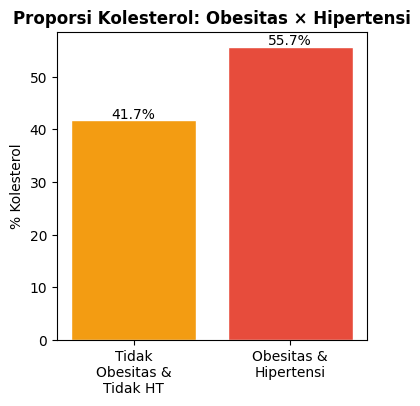

In [43]:
fig, ax3 = plt.subplots(figsize=(4, 4))

bars = ax3.bar(
    pivot_oxh_wide.index, 
    pivot_oxh_wide["Kolesterol"],
    color=["#f39c12", "#e74c3c"], 
    edgecolor="white"
)

ax3.set_ylabel("% Kolesterol")
wrapped_labels = [
    fill(label, width=10)
    for label in pivot_oxh_wide.index.astype(str)
]
ax3.set_xticks(range(len(wrapped_labels)))
ax3.set_xticklabels(wrapped_labels)
ax3.set_title("Proporsi Kolesterol: Obesitas × Hipertensi", fontweight="bold")

for bar in bars:
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center")

plt.show()

**Key insights**:
- **Visualisasi 1 - Proporsi catChol per Status Hipertensi**: Penderita hipertensi memiliki proporsi kolesterol tinggi yang jauh lebih besar (51.65% vs 37.80%). Sebaliknya, proporsi normal pada penderita hipertensi lebih rendah (14.79% vs 24.77%). Hal ini mengindikasikan hipertensi dan kolesterol tinggi cenderung terjadi bersamaan.
- **Visualisasi 2 - Heatmap**: Pasien dengan hipertensi memiliki rata-rata `totChol` yang lebih tinggi di semua kategori BMI. Dalam kelompok status hipertensi yang sama, BMI obese dan overweight memiliki kolesterol lebih tinggi dibanding BMI normal. Kombinasi terburuk ada pada pasien dengan status BMI overweight dan hipertensi dengan rata-rata `totChol` 247.2 sehingga dapat dikatakan pasien yang memiliki hipertensi dan overweight memiliki kecenderungan total kolesterol yang lebih tinggi. Namun, sebaiknya hal ini diuji secara statistik dengan metode yang dapat digunakan untuk data kategorik. Di sisi lain, kombinasi terbaik ada pada pasien dengan tanpa hipertensi dan BMI normal, dengan rata-rata total kolesterol terendah 226.5.
- **Visualisasi 3 - Proporsi Kolestetrol**: Individu dengan kombinasi obesitas dan hipertensi memiliki risiko kolesterol yang jauh lebih besar, yaitu 55.7% dibanding individu yang tidak hipertensi dan tidak obesitas.

## PB 5: Bagaimana perbedaan risiko kolesterol antara perokok dan non-perokok?

In [44]:
pivot_smoke = (
    df.groupby("currentSmoker")["totChol"]
    .agg(["mean", "median", "std"])
    .round(2)
)

pivot_smoke.index   = ["Non-Smoker", "Smoker"]
pivot_smoke.columns = ["Mean totChol", "Median totChol", "Std totChol"]
pivot_smoke

,Mean totChol,Median totChol,Std totChol
Non-Smoker,238.29,235.0,43.08
Smoker,233.91,232.0,42.60


In [45]:
pivot_smoke_age = (
    df.groupby(["age_group", "currentSmoker"])["totChol"]
    .mean()
    .unstack()
    .sort_index()
)

pivot_smoke_age.index = pd.CategoricalIndex(
    pivot_smoke_age.index,
    categories=["< 35", "35-55", "> 55"],
    ordered=True
)
pivot_smoke_age = pivot_smoke_age.sort_index()

pivot_smoke_age.columns = ["Non-Smoker", "Smoker"]
pivot_smoke_age

,Non-Smoker,Smoker
age_group,,
< 35,188.600000,196.428571
35-55,231.398683,231.885767
> 55,251.612081,243.356265


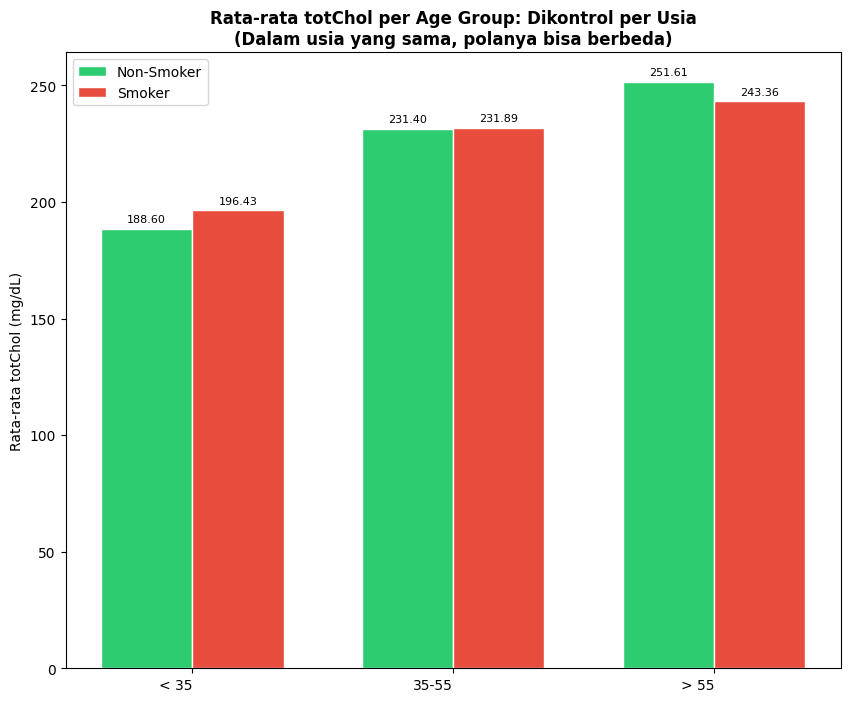

In [46]:
fig, ax1 = plt.subplots(figsize=(10, 8))

x = np.arange(len(pivot_smoke_age)); width = 0.35

bars1 = ax1.bar(x - width / 2, pivot_smoke_age["Non-Smoker"], 
        width,
        label="Non-Smoker", 
        color="#2ecc71", 
        edgecolor="white")

bars2 = ax1.bar(x + width / 2, pivot_smoke_age["Smoker"], 
        width,
        label="Smoker",
        color="#e74c3c", 
        edgecolor="white")

ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=8)
ax1.bar_label(bars2, fmt="%.2f", padding=3, fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(pivot_smoke_age.index.astype(str), ha="right")
ax1.set_ylabel("Rata-rata totChol (mg/dL)")
ax1.set_title("Rata-rata totChol per Age Group: Dikontrol per Usia\n"
              "(Dalam usia yang sama, polanya bisa berbeda)", fontweight="bold")
ax1.legend()
plt.show()

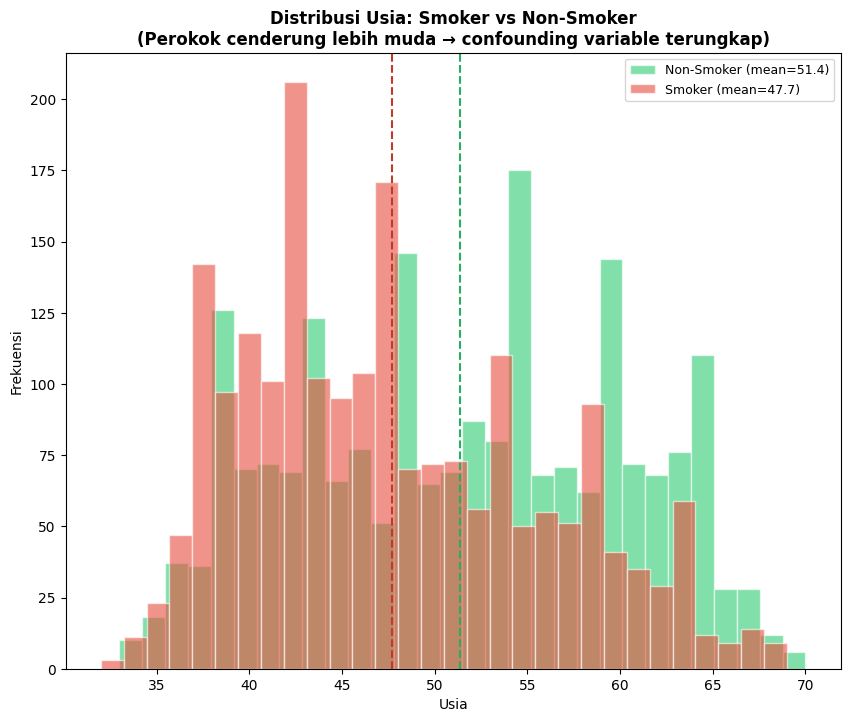

In [47]:
fig, ax2 = plt.subplots(figsize=(10, 8))

age_ns = df[df["currentSmoker"] == 0]["age"].dropna()
age_s  = df[df["currentSmoker"] == 1]["age"].dropna()

ax2.hist(
    age_ns, 
    bins=30, 
    alpha=0.6, 
    color="#2ecc71",
    label=f"Non-Smoker (mean={age_ns.mean():.1f})", 
    edgecolor="white")

ax2.hist(
    age_s, 
    bins=30, 
    alpha=0.6, 
    color="#e74c3c",
    label=f"Smoker (mean={age_s.mean():.1f})", 
    edgecolor="white")

ax2.axvline(age_ns.mean(), color="#27ae60", linestyle="--", linewidth=1.5)
ax2.axvline(age_s.mean(),  color="#c0392b", linestyle="--", linewidth=1.5)

ax2.set_xlabel("Usia"); ax2.set_ylabel("Frekuensi")
ax2.set_title("Distribusi Usia: Smoker vs Non-Smoker\n"
              "(Perokok cenderung lebih muda → confounding variable terungkap)",
              fontweight="bold")
ax2.legend(fontsize=9)
plt.show()

**Key insights**:
- **Visualisasi 1 - Groupbarchart**: Tidak terlihat ada perbedaan signifikan rata-rata `totChol` pada kelompok perokok dan non-perokok di semua kelompok usia.
- **Visualisasi 2 - Histogram**: Distribusi perokok condong ke kiri (usia lebih muda) dengan puncak sekitar usia 45-48 tahun. Sementara itu, distribusi non-perokok tersebar lebih merata. Hal ini berarti perokok pada dataset ini secara rata-rata lebih muda dibanding non-perokok.

## PB 6: Faktor apa saja yang paling kuat berhubungan dengan total kolesterol dan seberapa besar kekuatannya?

In [48]:
exclude_cols = ['catChol', 'age_group', 'bmi_category', 'smoking_intensity', 'glucose_risk', 'totChol']

numeric_cols = [col for col in df.columns 
                if col not in exclude_cols 
                and df[col].dtype in ['int64', 'float64']]

spearman_results = {}
for col in numeric_cols:
    r, p = spearmanr(df[col], df['totChol'], nan_policy='omit')
    spearman_results[col] = r

# Buat DataFrame hasil korelasi
spearman_df = pd.DataFrame(
    list(spearman_results.items()), 
    columns=["Faktor", "Spearman r"]
)

# Mapping nama kolom → label lebih readable (opsional tapi disarankan)
label_map = {
    'age'              : 'Usia',
    'sysBP'            : 'sysBP',
    'diaBP'            : 'diaBP',
    'pulse_pressure'   : 'Pulse Pressure',
    'bp_ratio'         : 'BP Ratio',
    'BMI'              : 'BMI',
    'totChol'          : 'totChol',
    'heartRate'        : 'Heart Rate',
    'glucose'          : 'Glucose',
    'cigsPerDay'       : 'Cigs/Day',
    'male'             : 'Gender (Male)',
    'currentSmoker'    : 'Merokok',
    'BPMeds'           : 'BP Meds',
    'prevalentStroke'  : 'Stroke',
    'prevalentHyp'     : 'Hipertensi',
    'diabetes'         : 'Diabetes',
    'highBP'           : 'High BP',
    'hyp_x_diabetes'   : 'Hipertensi×Diabetes',
    'smoker_x_age'     : 'Smoker×Usia',
    'obese_x_hyp'      : 'Obesitas×HT',
}
spearman_df['Faktor'] = spearman_df['Faktor'].map(label_map).fillna(spearman_df['Faktor'])
spearman_df.sort_values(by="Spearman r", ascending=False)

,Faktor,Spearman r
1,Usia,0.290479
8,sysBP,0.221757
9,diaBP,0.184699
13,Pulse Pressure,0.171948
15,High BP,0.165742
6,Hipertensi,0.159513
10,BMI,0.148163
11,Heart Rate,0.085146
14,BP Ratio,0.084903
4,BP Meds,0.075732


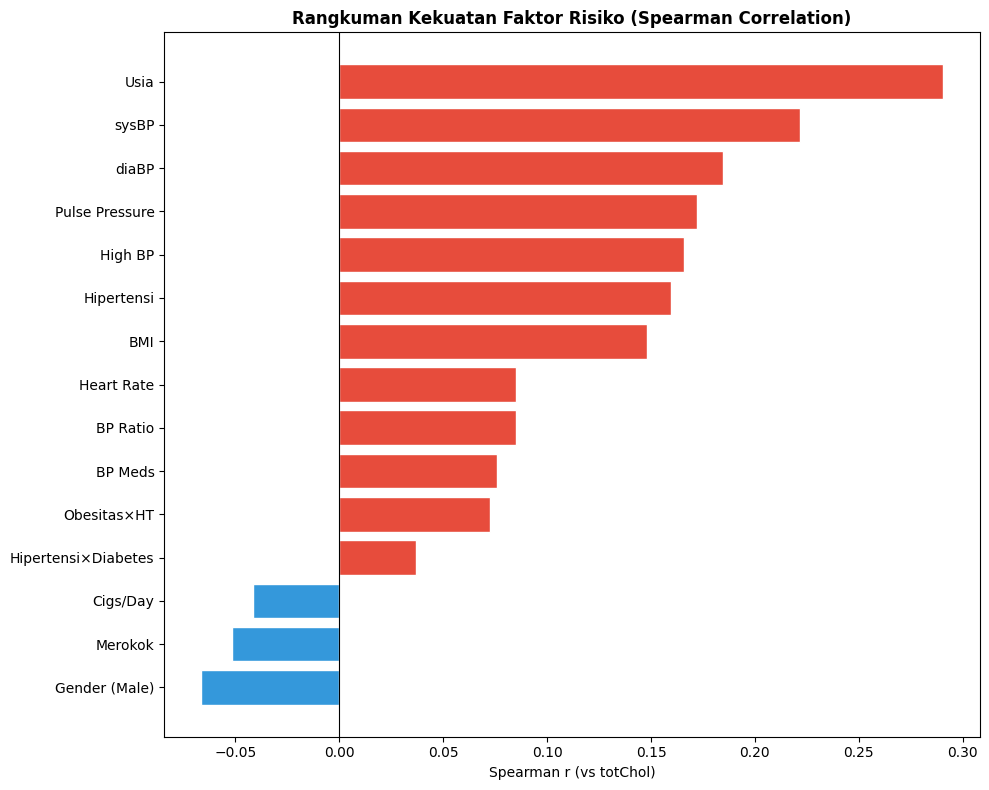

In [49]:
TOP_N = 15

rf_df = (
    spearman_df
    .assign(abs_r=spearman_df["Spearman r"].abs())
    .nlargest(TOP_N, "abs_r")
    .drop(columns="abs_r")
    .sort_values("Spearman r")
)

# plot
fig, ax1 = plt.subplots(figsize=(10, 8))

colors_rf = ["#e74c3c" if x >= 0 else "#3498db" for x in rf_df["Spearman r"]]
ax1.barh(
    rf_df["Faktor"], 
    rf_df["Spearman r"], 
    color=colors_rf, 
    edgecolor="white"
)

ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Spearman r (vs totChol)")
ax1.set_title("Rangkuman Kekuatan Faktor Risiko (Spearman Correlation)",
              fontweight="bold")

for i, val in enumerate(rf_df["Spearman r"]):
    offset = 0.003 if val >= 0 else -0.003
    ha     = "left"  if val >= 0 else "right"
    ax2.text(val + offset, i, f"{val:.2f}", va="center", ha=ha,
             fontsize=9)

plt.tight_layout()
plt.show()

**Key insights**:
- `Usia` merupakan faktor paling dominan dengan kuat korelasi positif 0.29, yang berarti semakin tua, semakin tinggi risiko kolesterol.
- Variabel terkait tekanan darah seperti `sysBP`, `diaBP`, `Pulse Pressure`, `HighBP`, dan `Hipertensi` berkontribusi paling banyak setelah `Usia` sehingga dapat dikatakan bahwa ada keterkaitan antara sistem kardiovaskular dengan risiko kolesterol.
- Secara keseluruhan, semua nilai r tergolong lemah hingga sedang (< 0.30), yang berarti kolesterol dipengaruhi oleh banyak faktor secara bersamaan dan bukan satu faktor tunggal. Hal ini juga tidak menutup kemungkinan ada faktor-faktor lain di luar analisis yang memengaruhi nilai kolesterol.

# Kesimpulan

**1. Seberapa banyak pasien dalam dataset ini yang memiliki kolesterol tinggi?** <br>
Mayoritas pasien dalam dataset ini berada dalam kondisi kolesterol . Hanya 21.2% (887 orang) yang masuk kategori normal (< 200 mg/dL), sementara 36.1% (1.507 orang) berada di kategori berisiko (200–239 mg/dL), dan 42.7% (1.786 orang) masuk ke kategori kolesterol tinggi (≥ 240 mg/dL). Dengan kata lain, hampir 4 dari 5 pasien memiliki kadar kolesterol di atas batas normal.

**2. Bagaimana perbedaan risiko kolesterol antara laki-laki dan perempuan?** <br>
Terdapat perbedaan yang signifikan secara statistik antara kedua kelompok gender (dibuktikan melalui A/B Testing dengan α = 0.05). Perempuan cenderung memiliki risiko kolesterol yang lebih besar, dengan 45.74% berada di kategori kolesterol tinggi. Sebaliknya, distribusi laki-laki lebih merata antara kategori berisiko (39.99%) dan kolesterol tinggi (38.77%).

**3. Apakah kelompok usia tertentu lebih rentan kolesterol tinggi?** <br>
Ya, usia menunjukkan hubungan yang cukup jelas terhadap risiko kolesterol. Terlihat ada kecenderungan di mana semakin bertambahnya usia, semakin tinggi pula risiko kolesterolnya. Hasil ini konsisten dengan nilai korelasi Spearman `Usia` terhadap `totChol` sebesar r=0.29 yang merupakan korelasi tertinggi di antara semua variabel.

**4. Apakah hipertensi dan obesitas memperburuk risiko kolesterol tinggi?** <br>
Ya, keduanya sama-sama meningkatkan risiko kolesterol, bahkan dampaknya lebih besar jika kedua kondisi tersebut terjadi bersamaan. Responden dengan kolesterol tinggi pada kelompok penderita hipertensi mencapai 51.65%, lebih tinggi dibandingkan kelompok tanpa hipertensi (37.80%). Selain itu, pasien dengan obesitas sekaligus hipertensi memiliki proporsi kolesterol lebih tinggi dibandingkan kelompok yang tidak mengalami keduanya, yaitu hingga 55.7%. Hasil heatmap rata-rata `totChol` juga menunjukkan pola yang mirip.

**5. Bagaimana perbedaan risiko kolesterol antara perokok dan non-perokok?** <br>
Secara keseluruhan, kelompok perokok terlihat memiliki rata-rata kolesterol yang sedikit lebih rendah dibandingkan nonperokok. Namun, jika dilihat dari kelompok usia, tidak terlihat ada perbedaan signifikan pada tiap kelompok. Hal ini kemungkinan terjadi karena perokok cenderung berusia lebih muda dibandingkan nonperokok dan responden dengan usia lebih muda cenderung memiliki kadar kolesterol lebih rendah (pada PB 2 diketahui kelompok usia < 35 yang berkategori normal sebanyak 66.67%), sehingga kelompok perokok terlihat memiliki kolesterol lebih rendah dibanding nonperokok.

**6. Faktor apa saja yang paling kuat berhubungan dengan total kolesterol dan seberapa besar kekuatannya?** <br>
Berdasarkan Spearman Correlation terhadap `totChol`, semua variabel memiliki nilai korelasi di bawah 0.30 (korelasi lemah-sedang). Beberapa faktor yang relatif lebih berpengaruh dibandingkan yang lain yaitu:
- `age` dengan nilai korelasi tertinggi (r=0.29).
- Variabel yang berkaitan dengan sistem kardiovaskular (`sysBP`, `diaBP`, `Pulse Pressure`, `HighBP`, dan `Hipertensi`)

Hasil ini mengindikasikan bahwa kolesterol merupakan kondisi multifaktorial, yang berarti variabel ini tidak dapat dijelaskan hanya oleh satu faktor saja, dan berkemungkinan juga dipengaruhi oleh faktor-faktor di luar dataset, seperti pola makan, aktivitas fisik, dan lain-lain.

In [50]:
df.to_csv("../data/df_cholesterol_cleaned.csv", index=False)

# Data Dictionary

## Variabel Asli (Raw Features)

| Kolom | Tipe | Nilai | Deskripsi |
|---|---|---|---|
| `male` | Kategorik (int) | 0 = Perempuan, 1 = Laki-laki | Jenis kelamin responden |
| `age` | Numerik (int) | 32–72 tahun | Usia responden dalam tahun |
| `currentSmoker` | Kategorik (int) | 0 = Non-perokok, 1 = Perokok | Status merokok saat ini |
| `cigsPerDay` | Numerik (float) | 0–70 batang/hari | Jumlah rokok yang dihisap per hari |
| `BPMeds` | Kategorik (int) | 0 = Tidak, 1 = Ya | Sedang mengonsumsi obat tekanan darah |
| `prevalentStroke` | Kategorik (int) | 0 = Tidak pernah, 1 = Pernah | Riwayat stroke |
| `prevalentHyp` | Kategorik (int) | 0 = Tidak, 1 = Hipertensi | Riwayat hipertensi |
| `diabetes` | Kategorik (int) | 0 = Tidak, 1 = Diabetes | Status diabetes |
| `sysBP` | Numerik (float) | mmHg | Tekanan darah sistolik |
| `diaBP` | Numerik (float) | mmHg | Tekanan darah diastolik |
| `BMI` | Numerik (float) | kg/m² | Body Mass Index / Indeks Massa Tubuh |
| `heartRate` | Numerik (float) | bpm | Detak jantung per menit |
| `glucose` | Numerik (float) | mg/dL | Kadar gula darah |
| `totChol` | Numerik (float) | mg/dL | **Target** – Total kolesterol darah |

## Variabel Hasil Feature Engineering

| Kolom | Tipe | Nilai / Kategori | Deskripsi |
|---|---|---|---|
| `pulse_pressure` | Numerik (float) | mmHg | Selisih tekanan darah: `sysBP − diaBP` |
| `bp_ratio` | Numerik (float) | ratio | Rasio tekanan darah: `sysBP / diaBP` |
| `age_group` | Kategorik (ordinal) | `< 35`, `35-55`, `> 55` | Kelompok usia hasil binning kolom `age` |
| `bmi_category` | Kategorik (ordinal) | `Underweight`, `Normal`, `Overweight`, `Obese` | Kategori BMI berdasarkan standar WHO |
| `smoking_intensity` | Kategorik (ordinal) | `None`, `Light`, `Moderate`, `Heavy` | Intensitas merokok dari kolom `cigsPerDay` |
| `glucose_risk` | Kategorik (ordinal) | `Normal`, `Prediabetes`, `Diabetes` | Kategori risiko gula darah dari kolom `glucose` |
| `highBP` | Kategorik (int) | 0 = Tidak, 1 = Ya | Flag hipertensi: `sysBP ≥ 140` atau `diaBP ≥ 90` |
| `hyp_x_diabetes` | Numerik (int) | 0 atau 1 | Interaksi: `prevalentHyp × diabetes` |
| `smoker_x_age` | Numerik (float) | — | Interaksi: `currentSmoker × age` (risiko merokok × usia) |
| `obese_x_hyp` | Numerik (int) | 0 atau 1 | Interaksi: `(BMI > 30) × prevalentHyp` (obesitas + hipertensi) |
| `catChol` | Kategorik (ordinal) | `Normal`, `Berisiko`, `Kolesterol` | Kategori kolesterol dari `totChol` (lihat threshold di bawah) |

## Threshold & Kategori Penting

### `catChol` (binning target `totChol`)
| Kategori | Rentang (mg/dL) | Keterangan |
|---|---|---|
| `Normal` | < 200 | Kolesterol normal |
| `Berisiko` | 200–239 | Borderline high |
| `Kolesterol` | ≥ 240 | Kolesterol tinggi |

### `bmi_category` (binning `BMI`)
| Kategori | Rentang (kg/m²) |
|---|---|
| `Underweight` | < 18.5 |
| `Normal` | 18.5–24.9 |
| `Overweight` | 25.0–29.9 |
| `Obese` | ≥ 30.0 |

### `smoking_intensity` (binning `cigsPerDay`)
| Kategori | Rentang (batang/hari) |
|---|---|
| `None` | 0 |
| `Light` | 1–10 |
| `Moderate` | 11–20 |
| `Heavy` | > 20 |

### `glucose_risk` (binning `glucose`)
| Kategori | Rentang (mg/dL) |
|---|---|
| `Normal` | ≤ 99 |
| `Prediabetes` | 100–125 |
| `Diabetes` | ≥ 126 |



## Ringkasan Dataset (Setelah Cleaning)

| Info | Nilai |
|---|---|
| Jumlah baris awal | 4.240 |
| Jumlah baris setelah cleaning | 4.180 |
| Baris dihapus | 60 (missing value pada `totChol`) |
| Jumlah kolom awal | 13 |
| Jumlah kolom setelah feature engineering | 24 |
| Missing value tersisa | Tidak ada |